## Notebook for classifying electrolyte solvents into different classes of functional groups

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw, Descriptors, PandasTools, rdMolDescriptors, Fragments
import thermo

### Assign functional group

In [2]:
df = pd.read_csv('../../datasets/label_unlabel_all_uniq_solvents.csv') ## 'expt_test' column: -1 = not tested, 0 = tested in initial training data, 1 = tested in batch 1, 2 = tested in batch 2, and so on...
df

,std_smiles,expt_test
0,CN(C)C=O,-1
1,CN1CCN(C)C1=O,-1
2,CN(C)C(=O)N(C)C,-1
3,CB(C)C=O,-1
4,[CH2]N(C)C=O,-1
...,...,...
388008,COCCOCC1CCCO1,0
388009,FC(F)COCCOCC(F)F,-1
388010,FC(F)COCCOCC(F)(F)F,-1
388011,FCCOCCF,-1


In [3]:
## non-exclusive classification
def ether_exlc_anhydride(mol):
    if thermo.is_anhydride(mol) == False and thermo.is_carbonate(mol) == False:
        if Fragments.fr_ether(mol) >= 1 and Fragments.fr_ether(mol) > Fragments.fr_ester(mol):
            return True
    elif thermo.is_anhydride(mol) == True and thermo.is_carbonate(mol) == False:
        if Fragments.fr_ether(mol) > 1 and Fragments.fr_ether(mol) > Fragments.fr_ester(mol):
            return True 
    elif thermo.is_carbonate(mol) == True:
        if Fragments.fr_ether(mol) >= 1 and Fragments.fr_ether(mol) < Fragments.fr_C_O(mol):
            return True
    else:
        return False
    
def ester_exlc_anhydride(mol):
    if thermo.is_anhydride(mol) == False:
        if Fragments.fr_ester(mol) >= 1:
            return True
    elif thermo.is_anhydride(mol) == True:
        if Fragments.fr_ester(mol) > 1:
            return True 
    else:
        return False

def calc_func_grp_frac(df, smiles_col):
    classes = {"Carbonate":[], "Sulfone":[], "Ether":[], "Ester":[], "Sulfoxide":[], "Sulfonyl fluoride":[], "Sulfonyl chloride":[], ## no Nitrile
            "Sulfonate ester":[], "Amine":[], "Amide":[], "Nitro":[], "Ketone":[], "Anhydride":[], "Imide":[], "Silyl ether":[], 
            "Phosphate": [], "Others":[]}
    class_arr = []
    for i in range(len(df)):
        if type(df[smiles_col][i]) == float:
            continue
        else:
            try:
                mol = Chem.MolFromSmiles(df[smiles_col][i])
                entry_classes = []
                if thermo.is_anhydride(mol):
                    classes['Anhydride'].append(df[smiles_col][i])
                    entry_classes.append('Anhydride')
                if thermo.is_sulfonate_ester(mol):
                    classes['Sulfonate ester'].append(df[smiles_col][i])
                    entry_classes.append('Sulfonate ester')
                if "S(=O)(=O)Cl" in df[smiles_col][i] and not thermo.is_sulfonate_ester(mol):
                    classes['Sulfonyl chloride'].append(df[smiles_col][i])
                    entry_classes.append('Sulfonyl chloride')
                if "S(=O)(=O)F" in df[smiles_col][i] and not thermo.is_sulfonate_ester(mol):
                    classes['Sulfonyl fluoride'].append(df[smiles_col][i])
                    entry_classes.append('Sulfonyl fluoride')
                if Fragments.fr_sulfone(mol) >= 1:
                    classes['Sulfone'].append(df[smiles_col][i])
                    entry_classes.append('Sulfone')
                if thermo.is_sulfoxide(mol):
                    classes['Sulfoxide'].append(df[smiles_col][i])
                    entry_classes.append('Sulfoxide')
                if thermo.is_carbonate(mol):
                    classes['Carbonate'].append(df[smiles_col][i])
                    entry_classes.append('Carbonate')
                if ester_exlc_anhydride(mol) == True:
                    classes['Ester'].append(df[smiles_col][i])
                    entry_classes.append('Ester')
                if Fragments.fr_nitrile(mol) >= 1: ## nitrile not present in this dataset
                    classes['Nitrile'].append(df[smiles_col][i])
                    entry_classes.append('Nitrile')
                if ether_exlc_anhydride(mol) == True:
                    classes['Ether'].append(df[smiles_col][i])
                    entry_classes.append('Ether')
                if thermo.is_ketone(mol):
                    classes['Ketone'].append(df[smiles_col][i])
                    entry_classes.append('Ketone')
                if Fragments.fr_amide(mol) >= 1 and Fragments.fr_amide(mol) > 2 * Fragments.fr_imide(mol):
                    classes['Amide'].append(df[smiles_col][i])
                    entry_classes.append('Amide')
                # if thermo.is_tertiary_amine(mol):
                if Fragments.fr_NH0(mol) >= 1 and Fragments.fr_NH0(mol) > Fragments.fr_amide(mol):
                    classes['Amine'].append(df[smiles_col][i])
                    entry_classes.append('Amine')
                if thermo.is_nitro(mol):
                    classes['Nitro'].append(df[smiles_col][i])
                    entry_classes.append('Nitro')
                # if thermo.is_imide(mol):
                if Fragments.fr_imide(mol):
                    classes['Imide'].append(df[smiles_col][i])
                    entry_classes.append('Imide')
                if thermo.is_silyl_ether(mol):
                    classes['Silyl ether'].append(df[smiles_col][i])
                    entry_classes.append('Silyl ether')
                if Fragments.fr_phos_ester(mol) >= 1:
                    classes['Phosphate'].append(df[smiles_col][i])
                    entry_classes.append('Phosphate')
                if not entry_classes:
                    classes['Others'].append(df[smiles_col][i])
                    entry_classes.append('Others')
            except AttributeError as e:
                print(f"Error processing SMILES: {df[smiles_col][i]}")
                continue
            class_arr.append(entry_classes)
    df['class'] = class_arr
    return df, classes, class_arr

In [4]:
df, classes, class_arr = calc_func_grp_frac(df, 'std_smiles')
df

[11:46:48] WARNING: not removing hydrogen atom without neighbors
[11:46:48] WARNING: not removing hydrogen atom without neighbors


,std_smiles,expt_test,class
0,CN(C)C=O,-1,[Amide]
1,CN1CCN(C)C1=O,-1,[Amide]
2,CN(C)C(=O)N(C)C,-1,[Amide]
3,CB(C)C=O,-1,[Others]
4,[CH2]N(C)C=O,-1,[Amide]
...,...,...,...
388008,COCCOCC1CCCO1,0,[Ether]
388009,FC(F)COCCOCC(F)F,-1,[Ether]
388010,FC(F)COCCOCC(F)(F)F,-1,[Ether]
388011,FCCOCCF,-1,[Ether]


In [10]:
# Step 1: Sort the lists in the 'class' column
df_curated = df.copy()
df_curated['class_sorted'] = df_curated['class'].apply(lambda x: tuple(sorted(x)))

# Step 2: Create a lookup table to map each unique tuple to a unique ID
unique_classes = df_curated['class_sorted'].drop_duplicates().reset_index(drop=True)
lookup_table = pd.DataFrame({
    'class_sorted': unique_classes,
    'class_id': range(len(unique_classes))
})

# Step 3: Merge the original DataFrame with the lookup table
df_curated = df_curated.merge(lookup_table, on='class_sorted', how='left')

# Drop the temporary 'class_sorted' column
df_curated.drop(columns=['class_sorted'], inplace=True)
df_curated

,std_smiles,expt_test,class,class_id
0,CN(C)C=O,-1,[Amide],0
1,CN1CCN(C)C1=O,-1,[Amide],0
2,CN(C)C(=O)N(C)C,-1,[Amide],0
3,CB(C)C=O,-1,[Others],1
4,[CH2]N(C)C=O,-1,[Amide],0
...,...,...,...,...
388008,COCCOCC1CCCO1,0,[Ether],7
388009,FC(F)COCCOCC(F)F,-1,[Ether],7
388010,FC(F)COCCOCC(F)(F)F,-1,[Ether],7
388011,FCCOCCF,-1,[Ether],7


In [ ]:
df_curated.to_json('../../datasets/label_unlabel_all_uniq_solvents_fgrp_class.json')
df_curated.to_csv('../../datasets/label_unlabel_all_uniq_solvents_fgrp_class.csv', index=False)

In [13]:
df_classes = pd.DataFrame.from_dict(classes, orient='index').T
df_classes

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,CN1COC(=O)OCN(C)C1=O,CN1CC(C)(S(=O)(=O)C2(C)CN(C)C(=O)N(C)C2=O)C(=O...,CN1COCN(C)C1=O,CN1CC(=O)OCC(=O)N(C)CC(=O)OCC(=O)N(C)CC(=O)OCC...,CN1CS(=O)N(C)C1=O,CO[Si](CCC(F)(F)C(F)(F)OC(F)(F)C(F)(F)S(=O)(=O...,CN(C)C(=O)S(=O)(=O)Cl,CCOP(=O)(OCC)OS(=O)(=O)OC,CN(C)[SiH]=O,CN(C)C=O,CCC[N+](=O)[O-],CN1CC(=O)CN(C)C1=O,O=COC=O,CN(C=O)C=O,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,CCOP(=O)(OP)OCC,CB(C)C=O
1,O=C(OF)OF,CN(C)C(=O)S(=O)(=O)C(=O)N(C)C,COC(=O)N(C)C,[CH2]C(=O)OC,CN1CS(=O)CN(C)C1=O,CN(C)C(=O)S(=O)(=O)F,CN1C(=O)N(C)C(CN2C(=O)N(C)C(C)(C)C2=O)(CS(=O)(...,CCOP(=O)(OCC)OS(C)(=O)=O,CN1CN(C)N(C)C1=O,CN1CCN(C)C1=O,CC(C)[N+](=O)[O-],CC(=O)[CH]N(C)C,CN(C)C(=O)OC=O,CN1CN(C)C(=O)N(C)C1=O,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,CCOP(=O)(OC)OCC,CB(C)CF
2,CN1OC(=O)ON(C)C1=O,CN1CS(=O)(=O)CN(C)C1=O,[CH2]OC(=O)N(C)C,COC(=O)C=O,CN1CN(C)S(=O)C1=O,CN(C)C(=O)N(C)S(=O)(=O)F,CN(C)C(=O)N(C)S(=O)(=O)Cl,COS(=O)(=O)C12C(=O)N(C)C(=O)N(C)C1N(C)C(=O)N2C,CN1CN(C)C(=O)N(C)C1,CN(C)C(=O)N(C)C,CCOC(=O)C[N+](=O)[O-],CC(=O)C=O,CN1CN(C)C(=O)OC1=O,CN1CC(=O)N(C)C1=O,CO[Si](CCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(...,COP(=O)(OC)OP,CCB(C)C
3,COC(=O)ON(C)C=O,CN1CN(C)C(=O)S(=O)(=O)C1,CN1COCC1=O,COC(=O)CF,CN1CN(C)S(=O)C1,CS(=O)(=O)F,COP(=O)(OC)S(=O)(=O)Cl,CCOP(=O)(OC)OS(C)(=O)=O,CN1CC(=O)N(C)C1,[CH2]N(C)C=O,COCC[N+](=O)[O-],CC(=O)C(=O)N(C)C,CN(C)C(=O)OC(=O)N(C)C,CN(C)C(=O)N(C)C=O,CO[Si](CCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C...,CCOP(=O)(OC)OOC,CB(C)C(C)=O
4,COC(=O)OF,CN(C)C(=O)S(C)(=O)=O,CB1CCOC1,[CH]OC(C)=O,CN1OS(=O)N(C)C1=O,CN(C)S(=O)(=O)F,CS(=O)(=O)Cl,COP(=O)(OC)OP(=O)(OC)OS(C)(=O)=O,CB1CCN(C)C1,[CH2]C(=O)N(C)C,O=[N+]([O-])C(Cl)(Cl)[N+](=O)[O-],[CH]C(=O)C=O,CC(=O)OC=O,CB1CN(C)C(=O)N(C)C1=O,CO[Si](C)(CCC(F)(F)C(F)(F)C(F)(F)C(F)(F)CC[Si]...,CCOP(=O)(OCC)OCC,CB(C)P=O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170080,None,None,None,None,None,None,None,None,None,CCN1CC(C(=O)N(C)CC(C)N(C)C)CC1=O,None,None,None,None,None,None,None
170081,None,None,None,None,None,None,None,None,None,O=C(CCCCl)N1CCCS(=O)(=O)CC1,None,None,None,None,None,None,None
170082,None,None,None,None,None,None,None,None,None,CCCCN1C(=O)OCC1[SiH](C)C,None,None,None,None,None,None,None
170083,None,None,None,None,None,None,None,None,None,CC(C)(C)C(=O)N1C2CCC1COC2,None,None,None,None,None,None,None


In [14]:
classes.keys()
classes_num = {key: len(classes[key]) for key in classes.keys()}
for keys in classes.keys():
    # print(keys)
    print("Class:", keys, "contains ", len(classes[keys]), "molecules", "with fraction of ", len(classes[keys])/len(df_curated)*100, "in the dataset")

classes_num
df_classes_num = pd.DataFrame.from_dict(classes_num, orient='index').T
df_classes_num

Class: Carbonate contains  1886 molecules with fraction of  0.4860661885039934 in the dataset
Class: Sulfone contains  6308 molecules with fraction of  1.625718725918977 in the dataset
Class: Ether contains  125524 molecules with fraction of  32.350462484504384 in the dataset
Class: Ester contains  68682 molecules with fraction of  17.700953318574378 in the dataset
Class: Sulfoxide contains  6693 molecules with fraction of  1.7249422055446595 in the dataset
Class: Sulfonyl fluoride contains  709 molecules with fraction of  0.1827258365054779 in the dataset
Class: Sulfonyl chloride contains  1122 molecules with fraction of  0.28916556919484654 in the dataset
Class: Sulfonate ester contains  7188 molecules with fraction of  1.8525152507776803 in the dataset
Class: Amine contains  131136 molecules with fraction of  33.796805777126025 in the dataset
Class: Amide contains  170085 molecules with fraction of  43.83487151203697 in the dataset
Class: Nitro contains  11 molecules with fraction o

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,1886,6308,125524,68682,6693,709,1122,7188,131136,170085,11,51000,4165,39701,12709,5077,32938


### Calculate fraction of ethers for suggested molecules from different batches: mutually exclusive method

#### Batch: 0 (training data)

In [15]:
df_b0 = pd.read_csv('../../../datasets/in-house_label_data.csv')
df_b0['std_smiles'] = df_b0.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b0

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,norm_capacity_16,norm_capacity_17,norm_capacity_18,norm_capacity_19,norm_capacity_20,norm_capacity_21,norm_capacity_22,norm_capacity_23,act_capacity_20,std_smiles
0,COCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.845301,-0.995151,1.062720,-0.357552,-0.308720,0.309456,0.693325,0.613072,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.48700,COCCOC
1,COCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.183255,-0.948338,0.615257,-0.582269,-1.010187,-0.522075,0.496896,0.301582,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.21900,COCCOC(C)C
2,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,0.421934,...,0.022967,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.75800,COCCOCC(C)C
3,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,0.421934,...,0.000360,0.000407,0.000600,0.000593,0.000447,0.000333,0.000000,0.000000,32.54300,COCCOCC(C)C
4,CCOCCOC(C)(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.879184,-1.539457,0.507075,-0.111830,0.800175,0.133053,0.926130,-0.208395,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.92800,CCOCCOC(C)(C)C
5,CCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.092295,-1.519334,-0.056200,-0.093036,-0.572012,-0.583818,-0.053796,-0.111619,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,93.06700,CCOCCOC(C)C
6,CCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.092295,-1.519334,-0.056200,-0.093036,-0.572012,-0.583818,-0.053796,-0.111619,...,0.135520,0.122253,0.109647,0.104447,0.098607,0.088353,0.000000,0.000000,96.55700,CCOCCOC(C)C
7,CCCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.067892,-1.253529,0.602357,0.775134,-0.714364,1.295648,0.646532,0.057886,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.75300,CCCCOCCOC
8,COCCOC1CCCC1,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.394637,-0.462672,0.854416,-0.416162,-1.007141,1.060702,0.662827,-0.394235,...,0.019633,0.021167,0.022867,0.026233,0.025507,0.025267,0.000000,0.000000,69.89100,COCCOC1CCCC1
9,CCCCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.075803,-1.758840,-0.316575,0.667843,-0.912376,0.097061,-0.035434,-0.602637,...,0.041993,0.037160,0.043613,0.046513,0.048480,0.050413,0.000000,0.000000,84.90000,CCCCOCCOC(C)C


In [16]:
tot_uniq_b0 = df_b0['std_smiles'].unique()
len(tot_uniq_b0)

26

In [17]:
df_b0_uniq = df_b0.drop_duplicates(subset=['std_smiles'])
df_b0_uniq.reset_index(drop=True, inplace=True)
df_b0_, classes_b0, class_arr_b0 = calc_func_grp_frac(df_b0_uniq, 'std_smiles')
df_b0_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,norm_capacity_17,norm_capacity_18,norm_capacity_19,norm_capacity_20,norm_capacity_21,norm_capacity_22,norm_capacity_23,act_capacity_20,std_smiles,class
0,COCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.845301,-0.995151,1.062720,-0.357552,-0.308720,0.309456,0.693325,0.613072,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,41.4870,COCCOC,[Ether]
1,COCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.183255,-0.948338,0.615257,-0.582269,-1.010187,-0.522075,0.496896,0.301582,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,99.2190,COCCOC(C)C,[Ether]
2,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,0.421934,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,26.7580,COCCOCC(C)C,[Ether]
3,CCOCCOC(C)(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.879184,-1.539457,0.507075,-0.111830,0.800175,0.133053,0.926130,-0.208395,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,3.9280,CCOCCOC(C)(C)C,[Ether]
4,CCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.092295,-1.519334,-0.056200,-0.093036,-0.572012,-0.583818,-0.053796,-0.111619,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,93.0670,CCOCCOC(C)C,[Ether]
5,CCCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.067892,-1.253529,0.602357,0.775134,-0.714364,1.295648,0.646532,0.057886,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,42.7530,CCCCOCCOC,[Ether]
6,COCCOC1CCCC1,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.394637,-0.462672,0.854416,-0.416162,-1.007141,1.060702,0.662827,-0.394235,...,0.021167,0.022867,0.026233,0.025507,0.025267,0.0,0.0,69.8910,COCCOC1CCCC1,[Ether]
7,CCCCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.075803,-1.758840,-0.316575,0.667843,-0.912376,0.097061,-0.035434,-0.602637,...,0.037160,0.043613,0.046513,0.048480,0.050413,0.0,0.0,84.9000,CCCCOCCOC(C)C,[Ether]
8,COCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.899245,-1.039674,1.079794,-0.351354,-0.360827,0.421555,0.804488,0.673995,...,0.000447,0.000447,0.000380,0.000427,0.000500,0.0,0.0,16.8020,COCCOCCOC,[Ether]
9,FC(F)(F)COCCOCCOCC(F)(F)F,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.657249,-1.593831,0.624976,-0.502685,0.783077,-0.000998,0.897057,0.013970,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,55.0350,FC(F)(F)COCCOCCOCC(F)(F)F,[Ether]


In [18]:
ether_len_b0 = len(set(classes_b0['Ether']))
ether_len_b0

23

In [19]:
frac_ether_0 = ether_len_b0/len(tot_uniq_b0)*100
frac_ether_0

88.46153846153845

In [20]:
classes_0_num = {key: len(classes_b0[key]) for key in classes_b0.keys()}
df_classes_0_num = pd.DataFrame.from_dict(classes_0_num, orient='index').T
df_classes_0_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,1,0,23,0,0,2,0,0,0,0,0,0,0,0,0,0,1


In [21]:
## mutually exclusive classification for ethers
only_ether_b0_tot = df_b0_[
    df_b0_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b0_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b0_tot

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,norm_capacity_17,norm_capacity_18,norm_capacity_19,norm_capacity_20,norm_capacity_21,norm_capacity_22,norm_capacity_23,act_capacity_20,std_smiles,class
0,COCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.845301,-0.995151,1.062720,-0.357552,-0.308720,0.309456,0.693325,0.613072,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,41.4870,COCCOC,[Ether]
1,COCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.183255,-0.948338,0.615257,-0.582269,-1.010187,-0.522075,0.496896,0.301582,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,99.2190,COCCOC(C)C,[Ether]
2,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,0.421934,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,26.7580,COCCOCC(C)C,[Ether]
3,CCOCCOC(C)(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.879184,-1.539457,0.507075,-0.111830,0.800175,0.133053,0.926130,-0.208395,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,3.9280,CCOCCOC(C)(C)C,[Ether]
4,CCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.092295,-1.519334,-0.056200,-0.093036,-0.572012,-0.583818,-0.053796,-0.111619,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,93.0670,CCOCCOC(C)C,[Ether]
5,CCCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.067892,-1.253529,0.602357,0.775134,-0.714364,1.295648,0.646532,0.057886,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,42.7530,CCCCOCCOC,[Ether]
6,COCCOC1CCCC1,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.394637,-0.462672,0.854416,-0.416162,-1.007141,1.060702,0.662827,-0.394235,...,0.021167,0.022867,0.026233,0.025507,0.025267,0.0,0.0,69.8910,COCCOC1CCCC1,[Ether]
7,CCCCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.075803,-1.758840,-0.316575,0.667843,-0.912376,0.097061,-0.035434,-0.602637,...,0.037160,0.043613,0.046513,0.048480,0.050413,0.0,0.0,84.9000,CCCCOCCOC(C)C,[Ether]
8,COCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.899245,-1.039674,1.079794,-0.351354,-0.360827,0.421555,0.804488,0.673995,...,0.000447,0.000447,0.000380,0.000427,0.000500,0.0,0.0,16.8020,COCCOCCOC,[Ether]
9,FC(F)(F)COCCOCCOCC(F)(F)F,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.657249,-1.593831,0.624976,-0.502685,0.783077,-0.000998,0.897057,0.013970,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,55.0350,FC(F)(F)COCCOCCOCC(F)(F)F,[Ether]


In [22]:
only_ether_b0_nonF = df_b0_[
    df_b0_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b0_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]
only_ether_b0_nonF

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,norm_capacity_17,norm_capacity_18,norm_capacity_19,norm_capacity_20,norm_capacity_21,norm_capacity_22,norm_capacity_23,act_capacity_20,std_smiles,class
0,COCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.845301,-0.995151,1.062720,-0.357552,-0.308720,0.309456,0.693325,0.613072,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,41.4870,COCCOC,[Ether]
1,COCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.183255,-0.948338,0.615257,-0.582269,-1.010187,-0.522075,0.496896,0.301582,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,99.2190,COCCOC(C)C,[Ether]
2,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,0.421934,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,26.7580,COCCOCC(C)C,[Ether]
3,CCOCCOC(C)(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.879184,-1.539457,0.507075,-0.111830,0.800175,0.133053,0.926130,-0.208395,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,3.9280,CCOCCOC(C)(C)C,[Ether]
4,CCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.092295,-1.519334,-0.056200,-0.093036,-0.572012,-0.583818,-0.053796,-0.111619,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,93.0670,CCOCCOC(C)C,[Ether]
5,CCCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.067892,-1.253529,0.602357,0.775134,-0.714364,1.295648,0.646532,0.057886,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,42.7530,CCCCOCCOC,[Ether]
6,COCCOC1CCCC1,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.394637,-0.462672,0.854416,-0.416162,-1.007141,1.060702,0.662827,-0.394235,...,0.021167,0.022867,0.026233,0.025507,0.025267,0.0,0.0,69.8910,COCCOC1CCCC1,[Ether]
7,CCCCOCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-1.075803,-1.758840,-0.316575,0.667843,-0.912376,0.097061,-0.035434,-0.602637,...,0.037160,0.043613,0.046513,0.048480,0.050413,0.0,0.0,84.9000,CCCCOCCOC(C)C,[Ether]
8,COCCOCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.899245,-1.039674,1.079794,-0.351354,-0.360827,0.421555,0.804488,0.673995,...,0.000447,0.000447,0.000380,0.000427,0.000500,0.0,0.0,16.8020,COCCOCCOC,[Ether]
21,COCCOCc1ccco1,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],-0.687319,-1.062975,1.246791,-0.438504,-0.324318,0.383256,0.514114,0.764953,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0306,COCCOCc1ccco1,[Ether]


In [23]:
frac_only_ether_tot_0 = len(only_ether_b0_tot['std_smiles'].unique())/len(tot_uniq_b0)*100
frac_only_ether_tot_0

76.92307692307693

In [24]:
frac_only_ether_nonF_0 = len(only_ether_b0_nonF['std_smiles'].unique())/len(tot_uniq_b0)*100
frac_only_ether_nonF_0

46.15384615384615

In [25]:
frac_only_ether_F_0 = frac_only_ether_tot_0 - frac_only_ether_nonF_0
# frac_only_ether_F_0 = (len(only_ether_b0_tot['std_smiles'].unique()) - len(only_ether_b0_nonF['std_smiles'].unique())) / len(tot_uniq_b0)*100
frac_only_ether_F_0

30.76923076923078

#### Batch: 1

In [26]:
df_b1 = pd.read_csv('../../datasets/batch-1/top_5000_suggestions_batch1_uniq_solvents.csv')
df_b1['std_smiles'] = df_b1.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b1

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles
0,COC1(C(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002300,8.438763e-07,6.042866e-07,0.716084,1.448163e-06,COC1(C(F)F)CCCCC1
1,COC1(C(F)(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002295,8.434955e-07,5.883782e-07,0.697547,1.431874e-06,COC1(C(F)(F)F)CCCC1
2,COC1(C(C)(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002259,8.364115e-07,5.906943e-07,0.706225,1.427106e-06,COC1(C(C)(F)F)CCCCC1
3,COC1(C(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002308,8.513511e-07,5.730075e-07,0.673057,1.424359e-06,COC1(C(F)F)CCCC1
4,COC1(F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002275,8.500037e-07,5.640064e-07,0.663534,1.414010e-06,COC1(F)CCCCC1
...,...,...,...,...,...,...,...,...,...
4995,COC1(N(C)C)CCCN(C=O)C1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001721,8.959106e-07,-2.235411e-07,-0.249513,6.723695e-07,COC1(N(C)C)CCCN(C=O)C1
4996,CC(C)S(=O)(=O)N1CCCC(=O)C1(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001751,8.938906e-07,-2.215512e-07,-0.247850,6.723394e-07,CC(C)S(=O)(=O)N1CCCC(=O)C1(C)C
4997,COC(C)(C)CN1CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001807,8.884141e-07,-2.160760e-07,-0.243215,6.723381e-07,COC(C)(C)CN1CCCC1
4998,CC1(C)CC(F)(F)CCC1=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001818,8.932022e-07,-2.208867e-07,-0.247298,6.723154e-07,CC1(C)CC(F)(F)CCC1=O


In [27]:
df_b1['rank'] = df_b1.index + 1
df_b1

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank
0,COC1(C(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002300,8.438763e-07,6.042866e-07,0.716084,1.448163e-06,COC1(C(F)F)CCCCC1,1
1,COC1(C(F)(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002295,8.434955e-07,5.883782e-07,0.697547,1.431874e-06,COC1(C(F)(F)F)CCCC1,2
2,COC1(C(C)(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002259,8.364115e-07,5.906943e-07,0.706225,1.427106e-06,COC1(C(C)(F)F)CCCCC1,3
3,COC1(C(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002308,8.513511e-07,5.730075e-07,0.673057,1.424359e-06,COC1(C(F)F)CCCC1,4
4,COC1(F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002275,8.500037e-07,5.640064e-07,0.663534,1.414010e-06,COC1(F)CCCCC1,5
...,...,...,...,...,...,...,...,...,...,...
4995,COC1(N(C)C)CCCN(C=O)C1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001721,8.959106e-07,-2.235411e-07,-0.249513,6.723695e-07,COC1(N(C)C)CCCN(C=O)C1,4996
4996,CC(C)S(=O)(=O)N1CCCC(=O)C1(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001751,8.938906e-07,-2.215512e-07,-0.247850,6.723394e-07,CC(C)S(=O)(=O)N1CCCC(=O)C1(C)C,4997
4997,COC(C)(C)CN1CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001807,8.884141e-07,-2.160760e-07,-0.243215,6.723381e-07,COC(C)(C)CN1CCCC1,4998
4998,CC1(C)CC(F)(F)CCC1=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001818,8.932022e-07,-2.208867e-07,-0.247298,6.723154e-07,CC1(C)CC(F)(F)CCC1=O,4999


In [28]:
tot_uniq_mol = df_b1['std_smiles'].unique()
len(tot_uniq_mol)

5000

In [29]:
df_b1_uniq = df_b1.drop_duplicates(subset=['std_smiles'])
df_b1_uniq.reset_index(drop=True, inplace=True)
df_b1_, classes_b1, class_arr_b1 = calc_func_grp_frac(df_b1_uniq, 'std_smiles')
df_b1_

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
0,COC1(C(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002300,8.438763e-07,6.042866e-07,0.716084,1.448163e-06,COC1(C(F)F)CCCCC1,1,[Ether]
1,COC1(C(F)(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002295,8.434955e-07,5.883782e-07,0.697547,1.431874e-06,COC1(C(F)(F)F)CCCC1,2,[Ether]
2,COC1(C(C)(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002259,8.364115e-07,5.906943e-07,0.706225,1.427106e-06,COC1(C(C)(F)F)CCCCC1,3,[Ether]
3,COC1(C(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002308,8.513511e-07,5.730075e-07,0.673057,1.424359e-06,COC1(C(F)F)CCCC1,4,[Ether]
4,COC1(F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002275,8.500037e-07,5.640064e-07,0.663534,1.414010e-06,COC1(F)CCCCC1,5,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...
4995,COC1(N(C)C)CCCN(C=O)C1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001721,8.959106e-07,-2.235411e-07,-0.249513,6.723695e-07,COC1(N(C)C)CCCN(C=O)C1,4996,"[Ether, Amide, Amine]"
4996,CC(C)S(=O)(=O)N1CCCC(=O)C1(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001751,8.938906e-07,-2.215512e-07,-0.247850,6.723394e-07,CC(C)S(=O)(=O)N1CCCC(=O)C1(C)C,4997,"[Ketone, Amine]"
4997,COC(C)(C)CN1CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001807,8.884141e-07,-2.160760e-07,-0.243215,6.723381e-07,COC(C)(C)CN1CCCC1,4998,"[Ether, Amine]"
4998,CC1(C)CC(F)(F)CCC1=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001818,8.932022e-07,-2.208867e-07,-0.247298,6.723154e-07,CC1(C)CC(F)(F)CCC1=O,4999,[Ketone]


In [30]:
ether_len_b1 = len(set(classes_b1['Ether']))
ether_len_b1

1136

In [31]:
frac_ether_1 = ether_len_b1/len(tot_uniq_mol)*100
frac_ether_1

22.720000000000002

In [32]:
classes_1_num = {key: len(classes_b1[key]) for key in classes_b1.keys()}
df_classes_1_num = pd.DataFrame.from_dict(classes_1_num, orient='index').T
df_classes_1_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,0,106,1136,36,45,3,4,21,2429,995,0,628,0,361,7,20,674


In [33]:
only_ether_b1_tot = df_b1_[
        df_b1_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
        ~df_b1_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
    ]
only_ether_b1_tot

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
0,COC1(C(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002300,8.438763e-07,6.042866e-07,0.716084,1.448163e-06,COC1(C(F)F)CCCCC1,1,[Ether]
1,COC1(C(F)(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002295,8.434955e-07,5.883782e-07,0.697547,1.431874e-06,COC1(C(F)(F)F)CCCC1,2,[Ether]
2,COC1(C(C)(F)F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002259,8.364115e-07,5.906943e-07,0.706225,1.427106e-06,COC1(C(C)(F)F)CCCCC1,3,[Ether]
3,COC1(C(F)F)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002308,8.513511e-07,5.730075e-07,0.673057,1.424359e-06,COC1(C(F)F)CCCC1,4,[Ether]
4,COC1(F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002275,8.500037e-07,5.640064e-07,0.663534,1.414010e-06,COC1(F)CCCCC1,5,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...
4861,CC1(F)CCCC(F)(F)O1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001809,8.948445e-07,-2.171631e-07,-0.242683,6.776813e-07,CC1(F)CCCC(F)(F)O1,4862,[Ether]
4900,COC1(C)CCCO1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001774,8.964602e-07,-2.202561e-07,-0.245695,6.762041e-07,COC1(C)CCCO1,4901,[Ether]
4945,COC1(C(F)(F)F)CCCCO1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001771,8.935533e-07,-2.190140e-07,-0.245105,6.745393e-07,COC1(C(F)(F)F)CCCCO1,4946,[Ether]
4952,COC1CCC(F)(F)CC1(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001822,8.952854e-07,-2.210960e-07,-0.246956,6.741894e-07,COC1CCC(F)(F)CC1(C)C,4953,[Ether]


In [34]:
only_ether_b1_nonF = df_b1_[
        df_b1_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
        ~df_b1_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
    ]
only_ether_b1_nonF

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
10,COC1(C)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002235,8.568427e-07,5.187529e-07,0.605424,1.375596e-06,COC1(C)CCCCC1,11,[Ether]
11,[CH]CC1(OC)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002245,8.608588e-07,5.075934e-07,0.589636,1.368452e-06,[CH]CC1(OC)CCCCC1,12,[Ether]
13,COC1(OC(C)C)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002257,8.654184e-07,4.945116e-07,0.571413,1.359930e-06,COC1(OC(C)C)CCCC1,14,[Ether]
17,COC1(C)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002235,8.642829e-07,4.833662e-07,0.559268,1.347649e-06,COC1(C)CCCC1,18,[Ether]
24,COC1(OC(C)(C)C)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.002197,8.607502e-07,4.543066e-07,0.527803,1.315057e-06,COC1(OC(C)(C)C)CCCCC1,25,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...
4624,CC(C)OC(C)(C)C(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000005,0.002026,9.098770e-07,-2.236924e-07,-0.245849,6.861846e-07,CC(C)OC(C)(C)C(C)(C)C,4625,[Ether]
4665,COOC1(C)CCCCO1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001770,8.986441e-07,-2.139337e-07,-0.238063,6.847105e-07,COOC1(C)CCCCO1,4666,[Ether]
4712,COC12CCCC(C)(CO1)C2,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001785,8.965575e-07,-2.136855e-07,-0.238340,6.828719e-07,COC12CCCC(C)(CO1)C2,4713,[Ether]
4900,COC1(C)CCCO1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001774,8.964602e-07,-2.202561e-07,-0.245695,6.762041e-07,COC1(C)CCCO1,4901,[Ether]


In [35]:
frac_only_ether_tot_1 = len(only_ether_b1_tot['std_smiles'].unique())/len(tot_uniq_mol)*100
frac_only_ether_tot_1

2.98

In [36]:
frac_only_ether_nonF_1 = len(only_ether_b1_nonF['std_smiles'].unique())/len(tot_uniq_mol)*100
frac_only_ether_nonF_1

1.3

In [37]:
frac_only_ether_F_1 = frac_only_ether_tot_1 - frac_only_ether_nonF_1
frac_only_ether_F_1

1.68

In [38]:
print(len(only_ether_b1_tot['std_smiles'].unique()))
print(len(only_ether_b1_nonF['std_smiles'].unique()))

149
65


#### Batch: 2

In [41]:
df_b2 = pd.read_csv('../../datasets/batch-2/top_5000_suggestions_batch2_uniq_solvents.csv')
df_b2['std_smiles'] = df_b2.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b2['rank'] = df_b2.index + 1
df_b2

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank
0,COCCC(C)(OC)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.374448e-06,0.001478,2.400529e-07,-1.399644e-07,-0.583056,1.000885e-07,COCCC(C)(OC)C(F)F,1
1,COCCOCC(C)(OC)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.494807e-06,0.001493,2.183637e-07,-1.199578e-07,-0.549348,9.840593e-08,COCCOCC(C)(OC)C(F)F,2
2,COCC(C)(COC)COCCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.600224e-06,0.001515,2.155350e-07,-1.176734e-07,-0.545960,9.786158e-08,COCC(C)(COC)COCCF,3
3,COCCC(F)(F)CC(C)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.523449e-06,0.001501,2.244459e-07,-1.292276e-07,-0.575763,9.521829e-08,COCCC(F)(F)CC(C)(F)F,4
4,COCCOCC(OC)C(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.366983e-06,0.001464,2.220979e-07,-1.286134e-07,-0.579084,9.348453e-08,COCCOCC(OC)C(C)(C)C,5
...,...,...,...,...,...,...,...,...,...,...
3753,COCC(CCl)(CN(C)C)CN(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.704869e-06,0.000934,9.056705e-08,-7.238532e-08,-0.799246,1.818173e-08,COCC(CCl)(CN(C)C)CN(C)C,3754
3754,COCCCN(C)OC(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.457475e-06,0.000870,9.051584e-08,-7.233746e-08,-0.799169,1.817838e-08,COCCCN(C)OC(C)C,3755
3755,COOCCOC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.038464e-06,0.001279,8.835231e-08,-7.017828e-08,-0.794300,1.817404e-08,COOCCOC(F)(F)F,3756
3756,COS(C)(OC)N(C)CC(C)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.748043e-06,0.000948,9.088904e-08,-7.271590e-08,-0.800051,1.817314e-08,COS(C)(OC)N(C)CC(C)(F)F,3757


In [42]:
tot_uniq_b2 = df_b2['std_smiles'].unique()
len(tot_uniq_b2)

3758

In [43]:
df_b2_uniq = df_b2.drop_duplicates(subset=['std_smiles'])
df_b2_uniq.reset_index(drop=True, inplace=True)
df_b2_, classes_b2, class_arr_b2 = calc_func_grp_frac(df_b2_uniq, 'std_smiles')
df_b2_

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
0,COCCC(C)(OC)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.374448e-06,0.001478,2.400529e-07,-1.399644e-07,-0.583056,1.000885e-07,COCCC(C)(OC)C(F)F,1,[Ether]
1,COCCOCC(C)(OC)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.494807e-06,0.001493,2.183637e-07,-1.199578e-07,-0.549348,9.840593e-08,COCCOCC(C)(OC)C(F)F,2,[Ether]
2,COCC(C)(COC)COCCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.600224e-06,0.001515,2.155350e-07,-1.176734e-07,-0.545960,9.786158e-08,COCC(C)(COC)COCCF,3,[Ether]
3,COCCC(F)(F)CC(C)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.523449e-06,0.001501,2.244459e-07,-1.292276e-07,-0.575763,9.521829e-08,COCCC(F)(F)CC(C)(F)F,4,[Ether]
4,COCCOCC(OC)C(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.366983e-06,0.001464,2.220979e-07,-1.286134e-07,-0.579084,9.348453e-08,COCCOCC(OC)C(C)(C)C,5,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...
3753,COCC(CCl)(CN(C)C)CN(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.704869e-06,0.000934,9.056705e-08,-7.238532e-08,-0.799246,1.818173e-08,COCC(CCl)(CN(C)C)CN(C)C,3754,"[Ether, Amine]"
3754,COCCCN(C)OC(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.457475e-06,0.000870,9.051584e-08,-7.233746e-08,-0.799169,1.817838e-08,COCCCN(C)OC(C)C,3755,"[Ether, Amine]"
3755,COOCCOC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,3.038464e-06,0.001279,8.835231e-08,-7.017828e-08,-0.794300,1.817404e-08,COOCCOC(F)(F)F,3756,[Ether]
3756,COS(C)(OC)N(C)CC(C)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.748043e-06,0.000948,9.088904e-08,-7.271590e-08,-0.800051,1.817314e-08,COS(C)(OC)N(C)CC(C)(F)F,3757,[Amine]


In [44]:
ether_len_b2 = len(set(classes_b2['Ether']))
ether_len_b2

2821

In [45]:
frac_ether_2 = ether_len_b2/len(tot_uniq_b2)*100
frac_ether_2

75.06652474720596

In [46]:
classes_2_num = {key: len(classes_b2[key]) for key in classes_b2.keys()}
df_classes_2_num = pd.DataFrame.from_dict(classes_2_num, orient='index').T
df_classes_2_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,0,14,2821,70,8,4,2,53,859,97,0,5,0,4,645,325,223


In [47]:
only_ether_b2_tot = df_b2_[
    df_b2_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b2_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b2_tot

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
0,COCCC(C)(OC)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001478,2.400529e-07,-1.399644e-07,-0.583056,1.000885e-07,COCCC(C)(OC)C(F)F,1,[Ether]
1,COCCOCC(C)(OC)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001493,2.183637e-07,-1.199578e-07,-0.549348,9.840593e-08,COCCOCC(C)(OC)C(F)F,2,[Ether]
2,COCC(C)(COC)COCCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001515,2.155350e-07,-1.176734e-07,-0.545960,9.786158e-08,COCC(C)(COC)COCCF,3,[Ether]
3,COCCC(F)(F)CC(C)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001501,2.244459e-07,-1.292276e-07,-0.575763,9.521829e-08,COCCC(F)(F)CC(C)(F)F,4,[Ether]
4,COCCOCC(OC)C(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001464,2.220979e-07,-1.286134e-07,-0.579084,9.348453e-08,COCCOCC(OC)C(C)(C)C,5,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...
3745,CCC(OC)OOC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000002,0.001040,9.035499e-08,-7.215286e-08,-0.798549,1.820213e-08,CCC(OC)OOC(C)(C)C,3746,[Ether]
3746,COCCC[CH]CC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001226,8.861065e-08,-7.041077e-08,-0.794608,1.819988e-08,COCCC[CH]CC(F)(F)F,3747,[Ether]
3749,CCC(OC)C(C)(C)OOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000002,0.001042,9.027389e-08,-7.208313e-08,-0.798494,1.819076e-08,CCC(OC)C(C)(C)OOC,3750,[Ether]
3752,COCC(CC(F)F)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001195,8.962346e-08,-7.143866e-08,-0.797098,1.818481e-08,COCC(CC(F)F)OC,3753,[Ether]


In [50]:
only_ether_b2_nonF = df_b2_[
    df_b2_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b2_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]
only_ether_b2_nonF

,solv_comb_sm,salt_comb_sm,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
4,COCCOCC(OC)C(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001464,2.220979e-07,-1.286134e-07,-0.579084,9.348453e-08,COCCOCC(OC)C(C)(C)C,5,[Ether]
5,COCCC(C)(C)OOC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000004,0.001494,2.075397e-07,-1.151357e-07,-0.554765,9.240399e-08,COCCC(C)(C)OOC(C)(C)C,6,[Ether]
26,COCCOCC(OC)OC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001411,2.129983e-07,-1.348212e-07,-0.632968,7.817719e-08,COCCOCC(OC)OC(C)(C)C,27,[Ether]
32,COCCCC(C)(C)OC(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001398,2.147043e-07,-1.382384e-07,-0.643855,7.646588e-08,COCCCC(C)(C)OC(C)C,33,[Ether]
37,COCCOCCOCC(C)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000003,0.001452,1.879153e-07,-1.142972e-07,-0.608238,7.361808e-08,COCCOCCOCC(C)(OC)OC,38,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...
3732,CCC(C)OCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000002,0.001070,8.197748e-08,-6.375218e-08,-0.777679,1.822530e-08,CCC(C)OCOC,3733,[Ether]
3735,CCCOCC(C)(C)OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000002,0.001098,9.010735e-08,-7.188732e-08,-0.797796,1.822003e-08,CCCOCC(C)(C)OCCOC,3736,[Ether]
3742,CCCC(COC(C)(C)C)OC,[Li+].F[P-](F)(F)(F)(F)F,0.000001,0.000859,8.970289e-08,-7.149729e-08,-0.797046,1.820559e-08,CCCC(COC(C)(C)C)OC,3743,[Ether]
3745,CCC(OC)OOC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000002,0.001040,9.035499e-08,-7.215286e-08,-0.798549,1.820213e-08,CCC(OC)OOC(C)(C)C,3746,[Ether]


In [48]:
frac_only_ether_tot_2 = len(only_ether_b2_tot['std_smiles'].unique())/len(tot_uniq_b2)*100
frac_only_ether_tot_2

32.9430548163917

In [51]:
frac_only_ether_nonF_2 = len(only_ether_b2_nonF['std_smiles'].unique())/len(tot_uniq_b2)*100
frac_only_ether_nonF_2

16.764236295902077

In [52]:
frac_only_ether_F_2 = frac_only_ether_tot_2 - frac_only_ether_nonF_2
frac_only_ether_F_2

16.178818520489624

#### Batch: 3

In [53]:
df_b3 = pd.read_csv('../../datasets/batch-3/top_10000_suggestions_batch3_uniq_solvents.csv')
df_b3['std_smiles'] = df_b3.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b3['rank'] = df_b3.index + 1
df_b3

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,amt_electrolyte,pressure_type,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank
0,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.371209,0.423985,0.087168,-0.390568,1.106635,0.478028,0.524065,0.414960,...,50,2,9.818468e-07,0.000796,1.144290e-07,-8.759247e-08,-3.263929,2.683651e-08,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,1
1,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.431278,0.458372,0.033057,-0.526323,1.347255,0.546517,0.808674,0.145876,...,50,2,9.729763e-07,0.000797,1.184382e-07,-9.013896e-08,-3.185212,2.829920e-08,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,2
2,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.369815,0.425456,0.086003,-0.388726,1.105710,0.477714,0.523496,0.416414,...,50,2,1.031936e-06,0.000794,9.934253e-08,-7.795002e-08,-3.643800,2.139251e-08,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,3
3,COC(=O)C(F)(F)C(F)(F)C(F)(F)C(=O)N(C)CCC[Si](O...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.538909,0.674474,0.272739,-0.443989,1.058057,0.533427,0.546245,0.314937,...,50,2,1.027699e-06,0.000792,9.836540e-08,-7.733640e-08,-3.677607,2.102900e-08,COC(=O)C(F)(F)C(F)(F)C(F)(F)C(=O)N(C)CCC[Si](O...,4
4,CO[Si](CCCCN(C)C(=O)N(C(=O)N(C)C)C(=O)N(C)CCCC...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.370517,0.607333,-0.126657,-0.230992,0.625624,0.741056,-0.063577,0.746594,...,50,2,8.526140e-07,0.000795,1.457390e-07,-1.048731e-07,-2.566271,4.086594e-08,CO[Si](CCCCN(C)C(=O)N(C(=O)N(C)C)C(=O)N(C)CCCC...,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8949,CCCN(C)CCCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.200232,-0.716220,-0.632898,0.237957,-0.464196,1.822570,0.894457,0.749287,...,50,2,9.301365e-07,0.000749,7.381771e-08,-5.988471e-08,-4.298050,1.393300e-08,CCCN(C)CCCCOCCOC,8950
8950,COCCN(C)CCC[Si](COC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.029200,-0.997617,-0.280489,-0.503384,-0.357378,1.088322,1.093044,1.384092,...,50,2,9.066336e-07,0.000738,6.721053e-08,-5.494478e-08,-4.479527,1.226576e-08,COCCN(C)CCC[Si](COC)(OC)OC,8951
8951,COCCOCCCN(C)CCCCl,[Li+].O=C1O[B-](F)(F)OC1=O,-0.951036,-0.576891,-0.254395,-0.465784,-0.325791,1.397665,1.032146,0.948021,...,50,2,9.882002e-07,0.000762,6.936447e-08,-5.653333e-08,-4.405945,1.283115e-08,COCCOCCCN(C)CCCCl,8952
8952,CCCCOCCN(CCC[Si](OC)(OC)OC)CCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.164254,-1.313408,-0.158492,0.408141,-0.805483,1.630553,0.830279,0.463970,...,50,2,9.512937e-07,0.000759,7.802918e-08,-6.290676e-08,-4.159836,1.512242e-08,CCCCOCCN(CCC[Si](OC)(OC)OC)CCOC,8953


In [54]:
tot_uniq_b3 = df_b3['std_smiles'].unique()
len(tot_uniq_b3)

8214

In [55]:
df_b3_uniq = df_b3.drop_duplicates(subset=['std_smiles'])
df_b3_uniq.reset_index(drop=True, inplace=True)
df_b3.reset_index(drop=True, inplace=True)
df_b3_, classes_b3, class_arr_b3 = calc_func_grp_frac(df_b3_uniq, 'std_smiles')
df_b3_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
0,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.371209,0.423985,0.087168,-0.390568,1.106635,0.478028,0.524065,0.414960,...,2,9.818468e-07,0.000796,1.144290e-07,-8.759247e-08,-3.263929,2.683651e-08,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,1,"[Amide, Silyl ether]"
1,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.431278,0.458372,0.033057,-0.526323,1.347255,0.546517,0.808674,0.145876,...,2,9.729763e-07,0.000797,1.184382e-07,-9.013896e-08,-3.185212,2.829920e-08,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,2,"[Amide, Silyl ether]"
2,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.369815,0.425456,0.086003,-0.388726,1.105710,0.477714,0.523496,0.416414,...,2,1.031936e-06,0.000794,9.934253e-08,-7.795002e-08,-3.643800,2.139251e-08,CO[Si](CCCN(C)C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,3,"[Amide, Silyl ether]"
3,COC(=O)C(F)(F)C(F)(F)C(F)(F)C(=O)N(C)CCC[Si](O...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.538909,0.674474,0.272739,-0.443989,1.058057,0.533427,0.546245,0.314937,...,2,1.027699e-06,0.000792,9.836540e-08,-7.733640e-08,-3.677607,2.102900e-08,COC(=O)C(F)(F)C(F)(F)C(F)(F)C(=O)N(C)CCC[Si](O...,4,"[Ester, Amide, Silyl ether]"
4,CO[Si](CCCCN(C)C(=O)N(C(=O)N(C)C)C(=O)N(C)CCCC...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.370517,0.607333,-0.126657,-0.230992,0.625624,0.741056,-0.063577,0.746594,...,2,8.526140e-07,0.000795,1.457390e-07,-1.048731e-07,-2.566271,4.086594e-08,CO[Si](CCCCN(C)C(=O)N(C(=O)N(C)C)C(=O)N(C)CCCC...,5,"[Imide, Silyl ether]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8209,CCCN(C)CCCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.200232,-0.716220,-0.632898,0.237957,-0.464196,1.822570,0.894457,0.749287,...,2,9.301365e-07,0.000749,7.381771e-08,-5.988471e-08,-4.298050,1.393300e-08,CCCN(C)CCCCOCCOC,8950,"[Ether, Amine]"
8210,COCCN(C)CCC[Si](COC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.029200,-0.997617,-0.280489,-0.503384,-0.357378,1.088322,1.093044,1.384092,...,2,9.066336e-07,0.000738,6.721053e-08,-5.494478e-08,-4.479527,1.226576e-08,COCCN(C)CCC[Si](COC)(OC)OC,8951,"[Ether, Amine, Silyl ether]"
8211,COCCOCCCN(C)CCCCl,[Li+].O=C1O[B-](F)(F)OC1=O,-0.951036,-0.576891,-0.254395,-0.465784,-0.325791,1.397665,1.032146,0.948021,...,2,9.882002e-07,0.000762,6.936447e-08,-5.653333e-08,-4.405945,1.283115e-08,COCCOCCCN(C)CCCCl,8952,"[Ether, Amine]"
8212,CCCCOCCN(CCC[Si](OC)(OC)OC)CCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.164254,-1.313408,-0.158492,0.408141,-0.805483,1.630553,0.830279,0.463970,...,2,9.512937e-07,0.000759,7.802918e-08,-6.290676e-08,-4.159836,1.512242e-08,CCCCOCCN(CCC[Si](OC)(OC)OC)CCOC,8953,"[Ether, Amine, Silyl ether]"


In [56]:
ether_len_b3 = len(set(classes_b3['Ether']))
ether_len_b3

4724

In [57]:
frac_ether_3 = ether_len_b3/len(tot_uniq_b3)*100
frac_ether_3

57.51156561967373

In [58]:
classes_3_num = {key: len(classes_b3[key]) for key in classes_b3.keys()}
df_classes_3_num = pd.DataFrame.from_dict(classes_3_num, orient='index').T
df_classes_3_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,4,38,4724,1390,37,4,14,162,4070,5513,0,286,7,562,935,501,32


In [59]:
only_ether_b3_tot = df_b3_[
    df_b3_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b3_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b3_tot

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
170,[CH]COCCOCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.763161,-1.560144,0.397419,0.104689,0.108550,0.259917,0.117034,0.236935,...,2,0.000002,0.001038,6.015766e-08,-4.152516e-08,-2.228642,1.863250e-08,[CH]COCCOCC,171,[Ether]
556,COCCOC(F)(F)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.125180,-1.051463,0.996493,-0.632885,-0.119763,-0.193613,1.180457,0.252873,...,2,0.000002,0.001112,6.940072e-08,-4.981938e-08,-2.544227,1.958134e-08,COCCOC(F)(F)C(F)F,557,[Ether]
557,COCCCOCCC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.817849,-1.279554,0.435669,-0.652919,0.006601,0.936679,1.618223,0.339943,...,2,0.000002,0.001090,8.733127e-08,-7.007600e-08,-4.061136,1.725527e-08,COCCCOCCC(F)(F)F,558,[Ether]
564,COCCOC(F)(F)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.940285,-1.074828,1.189192,-0.563295,0.208841,0.144812,1.221998,0.401600,...,2,0.000003,0.001195,7.968143e-08,-5.733954e-08,-2.566458,2.234190e-08,COCCOC(F)(F)C(F)(F)F,565,[Ether]
651,COCCOCCOCCC(C)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.067327,-1.118446,1.228769,-0.646023,0.445971,0.280729,1.692344,0.226943,...,2,0.000002,0.001133,7.978990e-08,-6.220767e-08,-3.538098,1.758223e-08,COCCOCCOCCC(C)(F)F,652,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7766,CCCCCCCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.190212,-1.355557,0.599166,1.109750,-0.792500,1.565449,0.576532,-0.024148,...,2,0.000002,0.000966,8.450347e-08,-6.811615e-08,-4.156638,1.638732e-08,CCCCCCCCOCCOC,8468,[Ether]
7776,CCOCCCCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.886386,-1.443757,0.612552,0.335451,-0.776195,1.244497,0.772113,0.269481,...,2,0.000002,0.001026,6.976253e-08,-5.723010e-08,-4.566558,1.253244e-08,CCOCCCCCCCOC,8478,[Ether]
7809,COCCCC(F)(F)C(F)(F)CF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.976364,-1.586375,0.981895,-0.387506,0.060011,0.458263,1.439131,0.444405,...,2,0.000002,0.001127,7.425146e-08,-6.018646e-08,-4.279165,1.406500e-08,COCCCC(F)(F)C(F)(F)CF,8512,[Ether]
7841,COCCCCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.837219,-1.040780,0.952668,0.086999,-0.651660,1.076659,0.883596,0.349644,...,2,0.000002,0.001049,7.413722e-08,-6.022474e-08,-4.328829,1.391248e-08,COCCCCCOCCOCCOC,8550,[Ether]


In [60]:
only_ether_b3_nonF = df_b3_[
    df_b3_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b3_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]
only_ether_b3_nonF

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,rank,class
170,[CH]COCCOCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.763161,-1.560144,0.397419,0.104689,0.108550,0.259917,0.117034,0.236935,...,2,0.000002,0.001038,6.015766e-08,-4.152516e-08,-2.228642,1.863250e-08,[CH]COCCOCC,171,[Ether]
797,COCCOCCOC(C)(C)COC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.050021,-1.055816,1.203546,-0.597428,0.276526,0.342787,1.585438,0.335842,...,2,0.000003,0.001164,8.080566e-08,-6.257968e-08,-3.433542,1.822598e-08,COCCOCCOC(C)(C)COC,798,[Ether]
941,COCCOCC(C)(C)OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.055111,-1.040548,1.187833,-0.583405,0.257582,0.316367,1.569820,0.339027,...,2,0.000003,0.001172,8.183741e-08,-6.296512e-08,-3.336378,1.887230e-08,COCCOCC(C)(C)OCCOC,942,[Ether]
1845,COCCOCCOCC(C)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.067564,-1.070836,1.236866,-0.600251,0.264436,0.331218,1.580490,0.330587,...,2,0.000003,0.001160,8.852632e-08,-6.668592e-08,-3.053329,2.184040e-08,COCCOCCOCC(C)(OC)OC,1846,[Ether]
1934,COCCOCC(C)(OC)OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.071109,-1.061505,1.234777,-0.602065,0.274543,0.340990,1.573086,0.334675,...,2,0.000003,0.001160,8.810587e-08,-6.660421e-08,-3.097630,2.150166e-08,COCCOCC(C)(OC)OCCOC,1935,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7749,CCCCCOCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.129421,-1.316570,0.587710,0.951480,-0.747496,1.431924,0.595776,0.029031,...,2,0.000002,0.000965,8.413477e-08,-6.787372e-08,-4.174004,1.626106e-08,CCCCCOCCOCCOCCOC,8451,[Ether]
7766,CCCCCCCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.190212,-1.355557,0.599166,1.109750,-0.792500,1.565449,0.576532,-0.024148,...,2,0.000002,0.000966,8.450347e-08,-6.811615e-08,-4.156638,1.638732e-08,CCCCCCCCOCCOC,8468,[Ether]
7776,CCOCCCCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.886386,-1.443757,0.612552,0.335451,-0.776195,1.244497,0.772113,0.269481,...,2,0.000002,0.001026,6.976253e-08,-5.723010e-08,-4.566558,1.253244e-08,CCOCCCCCCCOC,8478,[Ether]
7841,COCCCCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.837219,-1.040780,0.952668,0.086999,-0.651660,1.076659,0.883596,0.349644,...,2,0.000002,0.001049,7.413722e-08,-6.022474e-08,-4.328829,1.391248e-08,COCCCCCOCCOCCOC,8550,[Ether]


In [61]:
frac_only_ether_tot_3 = len(only_ether_b3_tot['std_smiles'].unique())/len(tot_uniq_b3)*100
frac_only_ether_tot_3

1.4730947163379595

In [62]:
frac_only_ether_nonF_3 = len(only_ether_b3_nonF['std_smiles'].unique())/len(tot_uniq_b3)*100
frac_only_ether_nonF_3

0.8278548819089359

In [63]:
frac_only_ether_F_3 = frac_only_ether_tot_3 - frac_only_ether_nonF_3
frac_only_ether_F_3

0.6452398344290237

#### Batch: 4

In [ ]:
df_b4 = pd.read_csv('../../datasets/batch-4/top_10000_suggestions_batch4_uniq_solvents.csv')
df_b4['std_smiles'] = df_b4.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b4['rank'] = df_b4.index + 1
df_b4

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,amt_electrolyte,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles
0,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.842454,-0.969284,0.843293,0.542591,0.659271,-1.028246,-0.227193,0.548413,...,50,2,1,3.809569e-07,0.000613,4.717666e-08,-3.970714e-08,-5.315888,7.469522e-09,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...
1,CN1C(=O)N2CN3C(=O)N4CN5C(=O)N(C)C6C5N(CN5C(=O)...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.140354,-0.922768,0.777714,0.484251,0.590515,-0.894770,-0.217753,0.316862,...,50,2,2,3.333645e-07,0.000585,3.230432e-08,-2.769543e-08,-6.009128,4.608893e-09,CN1C(=O)N2CN3C(=O)N4CN5C(=O)N(C)C6C5N(CN5C(=O)...
2,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.842454,-0.969284,0.843293,0.542591,0.659271,-1.028246,-0.227193,0.548413,...,50,2,3,4.195568e-07,0.000587,3.019479e-08,-2.597395e-08,-6.153732,4.220845e-09,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...
3,CN1CCCC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.244749,-0.718715,0.816326,0.622103,0.842643,-1.134638,0.343202,0.456895,...,50,2,4,4.778951e-07,0.000616,4.250074e-08,-3.603028e-08,-5.568422,6.470464e-09,CN1CCCC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...
4,CCCN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.545357,-1.096163,0.435487,1.288385,0.482219,-0.659059,-0.329151,0.365688,...,50,2,5,3.220242e-07,0.000620,5.466365e-08,-4.557863e-08,-5.016902,9.085015e-09,CCCN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8744,COCCOCCCCCCCCCCC[Si](OC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.908149,-0.944494,0.971822,0.043047,-0.735702,0.985443,0.804811,0.287560,...,50,2,8745,7.301459e-07,0.000644,2.668225e-08,-2.318253e-08,-6.624107,3.499721e-09,COCCOCCCCCCCCCCC[Si](OC)(OC)OC
8745,CO[Si](OC)(OC)C([Si](OC)(OC)OC)([Si](OC)(OC)OC...,[Li+].O=C1O[B-](F)(F)OC1=O,-0.473794,-1.393888,1.066949,-0.607220,0.353716,-0.159430,0.584239,-0.017302,...,50,2,8746,3.959835e-07,0.000585,3.002041e-08,-2.597474e-08,-6.420383,4.045668e-09,CO[Si](OC)(OC)C([Si](OC)(OC)OC)([Si](OC)(OC)OC...
8746,CCCCCCCCCCCCOCCOCCC[Si](OC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.076872,-1.681724,0.426816,1.007279,-0.740516,1.312715,0.261993,-0.277779,...,50,2,8747,5.599071e-07,0.000624,4.023875e-08,-3.430591e-08,-5.782378,5.932837e-09,CCCCCCCCCCCCOCCOCCC[Si](OC)(OC)OC
8747,COCCOCCCOCCCCCCCCCCC[Si](OC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.915870,-0.938476,0.970829,0.044332,-0.738988,0.996804,0.802128,0.293352,...,50,2,8748,6.721882e-07,0.000651,3.951917e-08,-3.366613e-08,-5.751911,5.853034e-09,COCCOCCCOCCCCCCCCCCC[Si](OC)(OC)OC


In [65]:
tot_uniq_b4 = df_b4['std_smiles'].unique()
len(tot_uniq_b4)

8749

In [ ]:
df_b4_uniq = df_b4.drop_duplicates(subset=['std_smiles'])
df_b4_uniq.reset_index(drop=True, inplace=True)
df_b4_, classes_b4, class_arr_b4 = calc_func_grp_frac(df_b4_uniq, 'std_smiles')
df_b4_

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
0,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.842454,-0.969284,0.843293,0.542591,0.659271,-1.028246,-0.227193,0.548413,...,2,1,3.809569e-07,0.000613,4.717666e-08,-3.970714e-08,-5.315888,7.469522e-09,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...,[Amide]
1,CN1C(=O)N2CN3C(=O)N4CN5C(=O)N(C)C6C5N(CN5C(=O)...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.140354,-0.922768,0.777714,0.484251,0.590515,-0.894770,-0.217753,0.316862,...,2,2,3.333645e-07,0.000585,3.230432e-08,-2.769543e-08,-6.009128,4.608893e-09,CN1C(=O)N2CN3C(=O)N4CN5C(=O)N(C)C6C5N(CN5C(=O)...,[Amide]
2,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.842454,-0.969284,0.843293,0.542591,0.659271,-1.028246,-0.227193,0.548413,...,2,3,4.195568e-07,0.000587,3.019479e-08,-2.597395e-08,-6.153732,4.220845e-09,CN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(...,[Amide]
3,CN1CCCC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,1.244749,-0.718715,0.816326,0.622103,0.842643,-1.134638,0.343202,0.456895,...,2,4,4.778951e-07,0.000616,4.250074e-08,-3.603028e-08,-5.568422,6.470464e-09,CN1CCCC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...,[Amide]
4,CCCN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.545357,-1.096163,0.435487,1.288385,0.482219,-0.659059,-0.329151,0.365688,...,2,5,3.220242e-07,0.000620,5.466365e-08,-4.557863e-08,-5.016902,9.085015e-09,CCCN1CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)CC(=O)N(C)C...,[Amide]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8744,COCCOCCCCCCCCCCC[Si](OC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.908149,-0.944494,0.971822,0.043047,-0.735702,0.985443,0.804811,0.287560,...,2,8745,7.301459e-07,0.000644,2.668225e-08,-2.318253e-08,-6.624107,3.499721e-09,COCCOCCCCCCCCCCC[Si](OC)(OC)OC,"[Ether, Silyl ether]"
8745,CO[Si](OC)(OC)C([Si](OC)(OC)OC)([Si](OC)(OC)OC...,[Li+].O=C1O[B-](F)(F)OC1=O,-0.473794,-1.393888,1.066949,-0.607220,0.353716,-0.159430,0.584239,-0.017302,...,2,8746,3.959835e-07,0.000585,3.002041e-08,-2.597474e-08,-6.420383,4.045668e-09,CO[Si](OC)(OC)C([Si](OC)(OC)OC)([Si](OC)(OC)OC...,[Silyl ether]
8746,CCCCCCCCCCCCOCCOCCC[Si](OC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-1.076872,-1.681724,0.426816,1.007279,-0.740516,1.312715,0.261993,-0.277779,...,2,8747,5.599071e-07,0.000624,4.023875e-08,-3.430591e-08,-5.782378,5.932837e-09,CCCCCCCCCCCCOCCOCCC[Si](OC)(OC)OC,"[Ether, Silyl ether]"
8747,COCCOCCCOCCCCCCCCCCC[Si](OC)(OC)OC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.915870,-0.938476,0.970829,0.044332,-0.738988,0.996804,0.802128,0.293352,...,2,8748,6.721882e-07,0.000651,3.951917e-08,-3.366613e-08,-5.751911,5.853034e-09,COCCOCCCOCCCCCCCCCCC[Si](OC)(OC)OC,"[Ether, Silyl ether]"


In [67]:
ether_len_b4 = len(set(classes_b4['Ether']))
ether_len_b4

4701

In [68]:
frac_ether_4 = ether_len_b4/len(tot_uniq_b4)*100
frac_ether_4

53.73185506915076

In [69]:
classes_4_num = {key: len(classes_b4[key]) for key in classes_b4.keys()}
df_classes_4_num = pd.DataFrame.from_dict(classes_4_num, orient='index').T
df_classes_4_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,11,33,4701,964,45,14,11,272,699,1398,0,281,16,636,891,1146,1809


In [70]:
only_ether_b4_tot = df_b4_[
    df_b4_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b4_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b4_tot

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
34,CCCOC(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.045926,-1.835682,0.106188,0.485531,-0.204883,-0.071057,-0.002451,-0.231103,...,2,35,1.263316e-06,0.000715,2.022999e-08,-1.680448e-08,-4.905700,3.425502e-09,CCCOC(F)F,[Ether]
55,[CH]OCCCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.033167,-1.833743,-0.012925,0.926882,0.026216,0.817101,0.027182,0.176470,...,2,56,1.250130e-06,0.000723,2.414859e-08,-1.990326e-08,-4.688272,4.245330e-09,[CH]OCCCC,[Ether]
73,CCCCOCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.737470,-1.823693,0.195215,0.814111,-0.089772,0.830827,0.182261,-0.364010,...,2,74,1.422296e-06,0.000784,2.661076e-08,-2.209353e-08,-4.890947,4.517230e-09,CCCCOCF,[Ether]
87,CCCC[CH]OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.996810,-1.713069,0.452806,0.726582,-0.153707,0.582916,0.021059,-0.035746,...,2,88,1.365263e-06,0.000755,2.344313e-08,-1.943578e-08,-4.850034,4.007349e-09,CCCC[CH]OC,[Ether]
102,CCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.185937,-1.761041,0.562131,0.697612,-0.655805,1.009843,0.605023,0.421360,...,2,103,1.885459e-06,0.000946,4.266663e-08,-3.479901e-08,-4.423072,7.867612e-09,CCCCOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8565,CCCCCCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.190212,-1.355557,0.599166,1.109750,-0.792500,1.565449,0.576532,-0.024148,...,2,8566,9.484232e-07,0.000678,2.379328e-08,-2.065936e-08,-6.592175,3.133921e-09,CCCCCCCOCCOCCOC,[Ether]
8661,CCCCCCOCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.190212,-1.355557,0.599166,1.109750,-0.792500,1.565449,0.576532,-0.024148,...,2,8662,9.377432e-07,0.000683,2.682971e-08,-2.321406e-08,-6.420430,3.615655e-09,CCCCCCOCCOCCOCCOC,[Ether]
8691,CCCCCOCCOCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.129421,-1.316570,0.587710,0.951480,-0.747496,1.431924,0.595776,0.029031,...,2,8692,8.943574e-07,0.000668,2.464153e-08,-2.138610e-08,-6.569376,3.255424e-09,CCCCCOCCOCCOCCOCCOC,[Ether]
8704,CCCCOCCOCCOCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.067892,-1.253529,0.602357,0.775134,-0.714364,1.295648,0.646532,0.057886,...,2,8705,8.866138e-07,0.000668,2.490011e-08,-2.163182e-08,-6.618694,3.268292e-09,CCCCOCCOCCOCCOCCOCCOC,[Ether]


In [71]:
only_ether_b4_nonF = df_b4_[
    df_b4_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b4_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]
only_ether_b4_nonF

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
55,[CH]OCCCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.033167,-1.833743,-0.012925,0.926882,0.026216,0.817101,0.027182,0.176470,...,2,56,1.250130e-06,0.000723,2.414859e-08,-1.990326e-08,-4.688272,4.245330e-09,[CH]OCCCC,[Ether]
87,CCCC[CH]OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.996810,-1.713069,0.452806,0.726582,-0.153707,0.582916,0.021059,-0.035746,...,2,88,1.365263e-06,0.000755,2.344313e-08,-1.943578e-08,-4.850034,4.007349e-09,CCCC[CH]OC,[Ether]
102,CCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.185937,-1.761041,0.562131,0.697612,-0.655805,1.009843,0.605023,0.421360,...,2,103,1.885459e-06,0.000946,4.266663e-08,-3.479901e-08,-4.423072,7.867612e-09,CCCCOC,[Ether]
113,[CH2]COCCCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.746231,-1.807363,0.110992,0.950203,-0.238493,0.859236,0.075456,-0.349111,...,2,114,1.373560e-06,0.000770,2.821040e-08,-2.319754e-08,-4.627606,5.012860e-09,[CH2]COCCCC,[Ether]
118,C[CH]OCCCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.693918,-1.730688,0.187816,1.180059,-0.063801,0.370095,0.194979,0.176968,...,2,119,1.299354e-06,0.000738,2.230929e-08,-1.860233e-08,-5.018226,3.706954e-09,C[CH]OCCCC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8077,CCCCOC(CC)CCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.247436,-1.836771,-0.155383,1.052265,-0.712956,0.022888,-0.020385,-0.247987,...,2,8078,1.192927e-06,0.000718,2.822692e-08,-2.306910e-08,-4.472646,5.157819e-09,CCCCOC(CC)CCC,[Ether]
8565,CCCCCCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.190212,-1.355557,0.599166,1.109750,-0.792500,1.565449,0.576532,-0.024148,...,2,8566,9.484232e-07,0.000678,2.379328e-08,-2.065936e-08,-6.592175,3.133921e-09,CCCCCCCOCCOCCOC,[Ether]
8661,CCCCCCOCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.190212,-1.355557,0.599166,1.109750,-0.792500,1.565449,0.576532,-0.024148,...,2,8662,9.377432e-07,0.000683,2.682971e-08,-2.321406e-08,-6.420430,3.615655e-09,CCCCCCOCCOCCOCCOC,[Ether]
8691,CCCCCOCCOCCOCCOCCOC,[Li+].F[P-](F)(F)(F)(F)F,-1.129421,-1.316570,0.587710,0.951480,-0.747496,1.431924,0.595776,0.029031,...,2,8692,8.943574e-07,0.000668,2.464153e-08,-2.138610e-08,-6.569376,3.255424e-09,CCCCCOCCOCCOCCOCCOC,[Ether]


In [72]:
frac_only_ether_tot_4 = len(only_ether_b4_tot['std_smiles'].unique())/len(tot_uniq_b4)*100
frac_only_ether_tot_4

12.63001485884101

In [73]:
frac_only_ether_nonF_4 = len(only_ether_b4_nonF['std_smiles'].unique())/len(tot_uniq_b4)*100
frac_only_ether_nonF_4

8.663847296833923

In [74]:
frac_only_ether_F_4 = frac_only_ether_tot_4 - frac_only_ether_nonF_4
frac_only_ether_F_4

3.9661675620070866

#### Batch 5

In [ ]:
df_b5 = pd.read_csv('../../datasets/batch-5/top_5000_suggestions_batch5_uniq_solvents.csv')
df_b5['std_smiles'] = df_b5.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b5['rank'] = df_b5.index + 1
df_b5

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,amt_electrolyte,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles
0,CCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.920924,-1.603036,0.550274,0.249128,-0.250719,0.486272,0.282188,0.202565,...,50,2,1,1.377135e-06,0.000729,1.646288e-08,-1.366268e-08,-4.879178,2.800201e-09,CCCOOC
1,[CH2]CCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.653605,-1.424194,0.878123,-0.406314,-0.163474,0.121483,0.449710,0.405105,...,50,2,2,1.554081e-06,0.000790,1.153646e-08,-9.914691e-09,-6.113494,1.621772e-09,[CH2]CCOOC
2,CCCOP(=O)(OC)OOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.976774,-1.307574,0.817352,0.341483,-0.258352,0.456097,0.319158,0.267196,...,50,2,3,1.414756e-06,0.000742,1.333075e-08,-1.127442e-08,-5.482795,2.056328e-09,CCCOP(=O)(OC)OOC
3,COCP(=O)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.879609,-0.651601,1.280382,-0.395084,0.304172,0.069591,0.741684,0.261875,...,50,2,4,1.588343e-06,0.000811,1.585504e-08,-1.336783e-08,-5.374617,2.487215e-09,COCP(=O)(OC)OC
4,CCCOP(=O)(OOC)OOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.968314,-1.300380,0.783393,0.353633,-0.220336,0.434773,0.277325,0.253531,...,50,2,5,1.329633e-06,0.000711,1.119901e-08,-9.563052e-09,-5.845538,1.635957e-09,CCCOP(=O)(OOC)OOC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,CCC(=O)CC(CCOC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.451813,-0.194807,0.881349,0.225478,-0.903288,-0.207091,0.387309,0.198267,...,50,2,4995,1.129130e-06,0.000668,1.558214e-08,-1.304327e-08,-5.137434,2.538868e-09,CCC(=O)CC(CCOC)OC
4995,FCCOCC(F)(F)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.645508,-1.686106,0.770590,-0.476692,0.716019,-0.145151,0.818991,0.095029,...,50,2,4996,1.599224e-06,0.000809,1.842024e-08,-1.526848e-08,-4.844427,3.151761e-09,FCCOCC(F)(F)C(F)(F)F
4996,COCOCOP=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.599196,-0.969392,0.889094,-0.231780,-0.288586,0.057383,0.397675,0.209634,...,50,2,4997,1.480941e-06,0.000762,1.163702e-08,-9.947592e-09,-5.888148,1.689426e-09,COCOCOP=O
4997,COCCOCCOCC(=O)OCC(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.660152,0.037751,1.085719,-0.276596,-0.883826,-0.435727,0.325705,0.298334,...,50,2,4998,1.200160e-06,0.000711,1.534372e-08,-1.305337e-08,-5.699309,2.290343e-09,COCCOCCOCC(=O)OCC(C)C


In [76]:
tot_uniq_b5 = df_b5['std_smiles'].unique()
len(tot_uniq_b5)

4999

In [ ]:
df_b5_uniq = df_b5.drop_duplicates(subset=['std_smiles'])
df_b5_uniq.reset_index(drop=True, inplace=True)
df_b5_, classes_b5, class_arr_b5 = calc_func_grp_frac(df_b5_uniq, 'std_smiles')
df_b5_

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
0,CCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.920924,-1.603036,0.550274,0.249128,-0.250719,0.486272,0.282188,0.202565,...,2,1,1.377135e-06,0.000729,1.646288e-08,-1.366268e-08,-4.879178,2.800201e-09,CCCOOC,[Others]
1,[CH2]CCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.653605,-1.424194,0.878123,-0.406314,-0.163474,0.121483,0.449710,0.405105,...,2,2,1.554081e-06,0.000790,1.153646e-08,-9.914691e-09,-6.113494,1.621772e-09,[CH2]CCOOC,[Others]
2,CCCOP(=O)(OC)OOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.976774,-1.307574,0.817352,0.341483,-0.258352,0.456097,0.319158,0.267196,...,2,3,1.414756e-06,0.000742,1.333075e-08,-1.127442e-08,-5.482795,2.056328e-09,CCCOP(=O)(OC)OOC,[Phosphate]
3,COCP(=O)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.879609,-0.651601,1.280382,-0.395084,0.304172,0.069591,0.741684,0.261875,...,2,4,1.588343e-06,0.000811,1.585504e-08,-1.336783e-08,-5.374617,2.487215e-09,COCP(=O)(OC)OC,[Ether]
4,CCCOP(=O)(OOC)OOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.968314,-1.300380,0.783393,0.353633,-0.220336,0.434773,0.277325,0.253531,...,2,5,1.329633e-06,0.000711,1.119901e-08,-9.563052e-09,-5.845538,1.635957e-09,CCCOP(=O)(OOC)OOC,[Others]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,CCC(=O)CC(CCOC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.451813,-0.194807,0.881349,0.225478,-0.903288,-0.207091,0.387309,0.198267,...,2,4995,1.129130e-06,0.000668,1.558214e-08,-1.304327e-08,-5.137434,2.538868e-09,CCC(=O)CC(CCOC)OC,"[Ether, Ketone]"
4995,FCCOCC(F)(F)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.645508,-1.686106,0.770590,-0.476692,0.716019,-0.145151,0.818991,0.095029,...,2,4996,1.599224e-06,0.000809,1.842024e-08,-1.526848e-08,-4.844427,3.151761e-09,FCCOCC(F)(F)C(F)(F)F,[Ether]
4996,COCOCOP=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.599196,-0.969392,0.889094,-0.231780,-0.288586,0.057383,0.397675,0.209634,...,2,4997,1.480941e-06,0.000762,1.163702e-08,-9.947592e-09,-5.888148,1.689426e-09,COCOCOP=O,[Ether]
4997,COCCOCCOCC(=O)OCC(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.660152,0.037751,1.085719,-0.276596,-0.883826,-0.435727,0.325705,0.298334,...,2,4998,1.200160e-06,0.000711,1.534372e-08,-1.305337e-08,-5.699309,2.290343e-09,COCCOCCOCC(=O)OCC(C)C,"[Ester, Ether]"


In [78]:
ether_len_b5 = len(set(classes_b5['Ether']))
ether_len_b5

4201

In [79]:
frac_ether_5 = ether_len_b5/len(tot_uniq_b5)*100
frac_ether_5

84.0368073614723

In [80]:
classes_5_num = {key: len(classes_b5[key]) for key in classes_b5.keys()}
df_classes_5_num = pd.DataFrame.from_dict(classes_5_num, orient='index').T
df_classes_5_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,6,33,4201,297,82,15,8,209,431,523,0,324,10,247,36,334,454


In [81]:
only_ether_b5_tot = df_b5_[
    df_b5_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b5_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b5_tot

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
12,COCCOC(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.199042,-1.114139,0.826715,-0.257876,-0.665296,-0.070154,0.607672,0.315459,...,2,13,0.000002,0.000877,2.086707e-08,-1.724921e-08,-4.767793,3.617861e-09,COCCOC(F)F,[Ether]
20,COCCCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.888535,-1.532757,0.907942,-0.240821,-0.416103,0.506808,0.882704,0.708297,...,2,21,0.000002,0.000955,2.158920e-08,-1.838183e-08,-5.731122,3.207371e-09,COCCCF,[Ether]
21,[CH]CCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867738,-1.496310,0.863331,-0.209246,-0.490123,0.541553,0.771578,0.738896,...,2,22,0.000002,0.000911,2.082090e-08,-1.757860e-08,-5.421653,3.242295e-09,[CH]CCOC,[Ether]
24,COCCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.890196,-1.534495,0.903516,-0.235866,-0.425754,0.534303,0.873815,0.685763,...,2,25,0.000002,0.000950,1.999585e-08,-1.712085e-08,-5.955070,2.875003e-09,COCCCOF,[Ether]
35,CCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.084384,-1.014022,0.862732,0.014255,-0.374000,0.614768,0.628171,0.548904,...,2,36,0.000002,0.000839,1.435790e-08,-1.222745e-08,-5.739360,2.130455e-09,CCOCCOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4977,COCCCCCCCC(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.262920,-1.527847,0.459590,0.478765,-1.112345,0.253068,0.803576,0.318226,...,2,4978,0.000002,0.000830,2.275904e-08,-1.867974e-08,-4.579156,4.079298e-09,COCCCCCCCC(F)F,[Ether]
4980,CCOCCC(OC)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.991909,-1.473980,0.739522,-0.192689,0.204690,0.370048,0.808526,0.095253,...,2,4981,0.000001,0.000756,1.540227e-08,-1.290459e-08,-5.166622,2.497684e-09,CCOCCC(OC)(OC)OC,[Ether]
4983,CCCCOCCCOCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.948577,-1.676686,0.484386,0.660827,-0.854012,1.322076,0.745136,0.142353,...,2,4984,0.000002,0.000811,1.545158e-08,-1.314267e-08,-5.692166,2.308905e-09,CCCCOCCCOCCCOC,[Ether]
4987,COCCOCCCOCOC(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.063074,-0.910760,0.459624,-0.359892,-1.201600,0.115489,0.676728,0.094745,...,2,4988,0.000002,0.000799,1.803500e-08,-1.513005e-08,-5.208380,2.904945e-09,COCCOCCCOCOC(C)C,[Ether]


In [82]:
only_ether_b5_nonF = df_b5_[
    df_b5_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b5_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]
only_ether_b5_nonF

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
21,[CH]CCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867738,-1.496310,0.863331,-0.209246,-0.490123,0.541553,0.771578,0.738896,...,2,22,0.000002,0.000911,2.082090e-08,-1.757860e-08,-5.421653,3.242295e-09,[CH]CCOC,[Ether]
35,CCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.084384,-1.014022,0.862732,0.014255,-0.374000,0.614768,0.628171,0.548904,...,2,36,0.000002,0.000839,1.435790e-08,-1.222745e-08,-5.739360,2.130455e-09,CCOCCOC,[Ether]
41,CCOCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.887899,-1.438661,0.657849,-0.046860,-0.210872,0.426636,0.357424,0.319410,...,2,42,0.000002,0.000777,1.796202e-08,-1.483203e-08,-4.738685,3.129989e-09,CCOCCOOC,[Ether]
49,CCOOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.049283,-0.965800,0.846165,-0.005860,-0.359979,0.526338,0.552423,0.506291,...,2,50,0.000002,0.000810,1.272350e-08,-1.087090e-08,-5.867911,1.852601e-09,CCOOCCOC,[Ether]
64,CCOCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.795624,-1.410743,0.580940,-0.057449,-0.022957,0.275826,0.158070,0.198010,...,2,65,0.000001,0.000671,1.169903e-08,-9.921397e-09,-5.581252,1.777629e-09,CCOCOOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946,COCCOC(C)(CCOC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.033504,-1.038946,1.212215,-0.593294,0.365025,0.228858,1.499244,0.270906,...,2,4947,0.000002,0.000974,3.589046e-08,-2.838703e-08,-3.783206,7.503432e-09,COCCOC(C)(CCOC)OC,[Ether]
4963,CCCOC(COC)(OC)OCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.138100,-1.454803,0.770224,0.014491,-0.034494,0.609712,0.865778,0.160418,...,2,4964,0.000001,0.000762,1.591374e-08,-1.335617e-08,-5.222214,2.557568e-09,CCCOC(COC)(OC)OCC,[Ether]
4980,CCOCCC(OC)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.991909,-1.473980,0.739522,-0.192689,0.204690,0.370048,0.808526,0.095253,...,2,4981,0.000001,0.000756,1.540227e-08,-1.290459e-08,-5.166622,2.497684e-09,CCOCCC(OC)(OC)OC,[Ether]
4983,CCCCOCCCOCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.948577,-1.676686,0.484386,0.660827,-0.854012,1.322076,0.745136,0.142353,...,2,4984,0.000002,0.000811,1.545158e-08,-1.314267e-08,-5.692166,2.308905e-09,CCCCOCCCOCCCOC,[Ether]


In [83]:
frac_only_ether_tot_5 = len(only_ether_b5_tot['std_smiles'].unique())/len(tot_uniq_b5)*100
frac_only_ether_tot_5

19.283856771354273

In [84]:
frac_only_ether_nonF_5 = len(only_ether_b5_nonF['std_smiles'].unique())/len(tot_uniq_b5)*100
frac_only_ether_nonF_5

11.98239647929586

In [85]:
frac_only_ether_F_5 = frac_only_ether_tot_5 - frac_only_ether_nonF_5
frac_only_ether_F_5

7.3014602920584135

#### Batch 6

In [ ]:
df_b6 = pd.read_csv('../../datasets/batch-6/top_5000_suggestions_batch6_uniq_solvents.csv')
df_b6['std_smiles'] = df_b6.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b6['rank'] = df_b6.index + 1
df_b6

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,amt_electrolyte,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles
0,COCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.863536,-1.039067,1.081461,-0.406529,-0.227115,0.260969,0.755056,0.576431,...,50,2,1095.0,1.846807e-06,0.000938,1.757061e-08,-1.520749e-08,-6.435340,2.363121e-09,COCCOF
1,[CH2]CCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.653605,-1.424194,0.878123,-0.406314,-0.163474,0.121483,0.449710,0.405105,...,50,2,3925.0,1.573056e-06,0.000830,9.237026e-09,-8.166634e-09,-7.629569,1.070393e-09,[CH2]CCOOC
2,COCB(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.608169,-1.441212,0.926965,-0.546185,-0.079639,0.040126,0.487229,0.370232,...,50,2,4329.0,1.562349e-06,0.000826,8.804825e-09,-7.798488e-09,-7.749381,1.006337e-09,COCB(F)F
3,COCCO[Al],[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.843809,-0.989662,1.069399,-0.365416,-0.311995,0.308275,0.678411,0.599304,...,50,2,1636.0,1.779212e-06,0.000910,1.453641e-08,-1.267635e-08,-6.815016,1.860062e-09,COCCO[Al]
4,COCCB=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.801731,-1.105580,1.083006,-0.354707,-0.315271,0.212797,0.668411,0.618927,...,50,2,1185.0,1.840186e-06,0.000939,1.722264e-08,-1.495731e-08,-6.602702,2.265332e-09,COCCB=O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,COCCCCCOOCCCOOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.963041,-1.537202,0.930112,-0.000216,-0.598388,0.780594,0.817360,0.704008,...,50,2,4797.0,1.271594e-06,0.000741,8.333448e-09,-7.393424e-09,-7.865138,9.400247e-10,COCCCCCOOCCCOOC
3656,COCCC1CCCN(C(=O)C(F)F)C1,[Li+].O=C1O[B-](F)(F)OC1=O,0.751896,0.844789,0.729120,0.442497,-1.227714,-0.132727,1.217904,-0.219517,...,50,2,3226.0,5.196018e-07,0.000567,1.029346e-08,-9.081568e-09,-7.493699,1.211894e-09,COCCC1CCCN(C(=O)C(F)F)C1
3657,COCCC1CCCN(CC=O)C1,[Li+].O=C1O[B-](F)(F)OC1=O,1.183272,-0.146497,0.667712,0.318337,-1.237932,0.317185,1.474304,0.149830,...,50,2,1009.0,1.045575e-06,0.000710,1.843212e-08,-1.593775e-08,-6.389482,2.494372e-09,COCCC1CCCN(CC=O)C1
3658,COC1CCCCCC(=O)OC(C)C1,[Li+].O=C1O[B-](F)(F)OC1=O,1.135297,-0.466424,0.870969,-0.693492,-0.429577,0.719366,-0.422886,-0.750610,...,50,2,3983.0,5.996270e-07,0.000567,8.686140e-09,-7.627014e-09,-7.201240,1.059125e-09,COC1CCCCCC(=O)OC(C)C1


In [87]:
tot_uniq_b6 = df_b6['std_smiles'].unique()
len(tot_uniq_b6)

3660

In [ ]:
df_b6_uniq = df_b6.drop_duplicates(subset=['std_smiles'])
df_b6_uniq.reset_index(drop=True, inplace=True)
df_b6_, classes_b6, class_arr_b6 = calc_func_grp_frac(df_b6_uniq, 'std_smiles')
df_b6_

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
0,COCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.863536,-1.039067,1.081461,-0.406529,-0.227115,0.260969,0.755056,0.576431,...,2,1095.0,1.846807e-06,0.000938,1.757061e-08,-1.520749e-08,-6.435340,2.363121e-09,COCCOF,[Ether]
1,[CH2]CCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.653605,-1.424194,0.878123,-0.406314,-0.163474,0.121483,0.449710,0.405105,...,2,3925.0,1.573056e-06,0.000830,9.237026e-09,-8.166634e-09,-7.629569,1.070393e-09,[CH2]CCOOC,[Others]
2,COCB(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.608169,-1.441212,0.926965,-0.546185,-0.079639,0.040126,0.487229,0.370232,...,2,4329.0,1.562349e-06,0.000826,8.804825e-09,-7.798488e-09,-7.749381,1.006337e-09,COCB(F)F,[Ether]
3,COCCO[Al],[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.843809,-0.989662,1.069399,-0.365416,-0.311995,0.308275,0.678411,0.599304,...,2,1636.0,1.779212e-06,0.000910,1.453641e-08,-1.267635e-08,-6.815016,1.860062e-09,COCCO[Al],[Ether]
4,COCCB=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.801731,-1.105580,1.083006,-0.354707,-0.315271,0.212797,0.668411,0.618927,...,2,1185.0,1.840186e-06,0.000939,1.722264e-08,-1.495731e-08,-6.602702,2.265332e-09,COCCB=O,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,COCCCCCOOCCCOOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.963041,-1.537202,0.930112,-0.000216,-0.598388,0.780594,0.817360,0.704008,...,2,4797.0,1.271594e-06,0.000741,8.333448e-09,-7.393424e-09,-7.865138,9.400247e-10,COCCCCCOOCCCOOC,[Ether]
3656,COCCC1CCCN(C(=O)C(F)F)C1,[Li+].O=C1O[B-](F)(F)OC1=O,0.751896,0.844789,0.729120,0.442497,-1.227714,-0.132727,1.217904,-0.219517,...,2,3226.0,5.196018e-07,0.000567,1.029346e-08,-9.081568e-09,-7.493699,1.211894e-09,COCCC1CCCN(C(=O)C(F)F)C1,"[Ether, Amide]"
3657,COCCC1CCCN(CC=O)C1,[Li+].O=C1O[B-](F)(F)OC1=O,1.183272,-0.146497,0.667712,0.318337,-1.237932,0.317185,1.474304,0.149830,...,2,1009.0,1.045575e-06,0.000710,1.843212e-08,-1.593775e-08,-6.389482,2.494372e-09,COCCC1CCCN(CC=O)C1,"[Ether, Amine]"
3658,COC1CCCCCC(=O)OC(C)C1,[Li+].O=C1O[B-](F)(F)OC1=O,1.135297,-0.466424,0.870969,-0.693492,-0.429577,0.719366,-0.422886,-0.750610,...,2,3983.0,5.996270e-07,0.000567,8.686140e-09,-7.627014e-09,-7.201240,1.059125e-09,COC1CCCCCC(=O)OC(C)C1,"[Ester, Ether]"


In [89]:
ether_len_b6 = len(set(classes_b6['Ether']))
ether_len_b6

3231

In [90]:
frac_ether_6 = ether_len_b6/len(tot_uniq_b6)*100
frac_ether_6

88.27868852459017

In [91]:
classes_6_num = {key: len(classes_b6[key]) for key in classes_b6.keys()}
df_classes_6_num = pd.DataFrame.from_dict(classes_6_num, orient='index').T
df_classes_6_num

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,1,34,3231,146,40,9,0,121,525,618,1,244,5,202,38,219,143


In [92]:
only_ether_b6_tot = df_b6_[
    df_b6_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b6_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b6_tot

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
0,COCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.863536,-1.039067,1.081461,-0.406529,-0.227115,0.260969,0.755056,0.576431,...,2,1095.0,0.000002,0.000938,1.757061e-08,-1.520749e-08,-6.435340,2.363121e-09,COCCOF,[Ether]
6,COCCOOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867386,-1.041068,1.083540,-0.400942,-0.225466,0.304233,0.783784,0.599485,...,2,1037.0,0.000002,0.000947,1.808197e-08,-1.563062e-08,-6.376345,2.451345e-09,COCCOOF,[Ether]
8,COCCOCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.911145,-1.066285,1.151899,-0.429532,-0.251716,0.344949,0.850132,0.616512,...,2,620.0,0.000002,0.000990,2.295538e-08,-1.963644e-08,-5.916481,3.318939e-09,COCCOCF,[Ether]
9,[CH]OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.910130,-0.953172,0.851844,-0.359861,-0.277796,0.518528,0.729742,0.808529,...,2,2377.0,0.000002,0.000877,1.217593e-08,-1.070015e-08,-7.250541,1.475773e-09,[CH]OCCOC,[Ether]
10,COCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.849004,-1.005167,1.071053,-0.361889,-0.316253,0.341838,0.721685,0.625580,...,2,1353.0,0.000002,0.000928,1.595627e-08,-1.387214e-08,-6.656096,2.084126e-09,COCCOOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3630,COCCCOCCCOCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.769474,-0.981440,0.921684,-0.107981,-0.589646,0.904724,0.897114,0.414993,...,2,2871.0,0.000001,0.000761,1.087086e-08,-9.565994e-09,-7.331029,1.304864e-09,COCCCOCCCOCCOCCOC,[Ether]
3639,COCCOCCCCCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.828283,-1.040234,0.946592,0.085435,-0.626659,1.036216,0.847144,0.315897,...,2,1859.0,0.000001,0.000801,1.350572e-08,-1.179212e-08,-6.881471,1.713604e-09,COCCOCCCCCCOCCOC,[Ether]
3648,CCCOCCOCCCOCCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.877738,-1.596169,0.522391,0.412222,-0.835663,1.200644,0.817318,0.236686,...,2,4174.0,0.000001,0.000728,8.913635e-09,-7.885457e-09,-7.669350,1.028178e-09,CCCOCCOCCCOCCCOC,[Ether]
3649,COCCOCCOC1CCCC1,[Li+].O=C1O[B-](F)(F)OC1=O,0.340693,-0.507196,0.871490,-0.409964,-1.059248,1.172802,0.773990,-0.333313,...,2,43.0,0.000002,0.000966,4.888250e-08,-3.987019e-08,-4.423972,9.012307e-09,COCCOCCOC1CCCC1,[Ether]


In [93]:
only_ether_b6_nonF = df_b6_[
    df_b6_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b6_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]
only_ether_b6_nonF

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
9,[CH]OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.910130,-0.953172,0.851844,-0.359861,-0.277796,0.518528,0.729742,0.808529,...,2,2377.0,0.000002,0.000877,1.217593e-08,-1.070015e-08,-7.250541,1.475773e-09,[CH]OCCOC,[Ether]
10,COCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.849004,-1.005167,1.071053,-0.361889,-0.316253,0.341838,0.721685,0.625580,...,2,1353.0,0.000002,0.000928,1.595627e-08,-1.387214e-08,-6.656096,2.084126e-09,COCCOOC,[Ether]
18,[CH]CCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867738,-1.496310,0.863331,-0.209246,-0.490123,0.541553,0.771578,0.738896,...,2,414.0,0.000002,0.001004,2.786140e-08,-2.361395e-08,-5.559566,4.247445e-09,[CH]CCOC,[Ether]
19,[CH2]OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.815045,-0.981745,1.062964,-0.349766,-0.283044,0.333308,0.639936,0.666762,...,2,4054.0,0.000002,0.000817,9.134116e-09,-8.084382e-09,-7.701367,1.049733e-09,[CH2]OCCOC,[Ether]
34,[CH2]COCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.919906,-1.049955,1.067676,-0.293440,-0.400436,0.373358,0.743327,0.631411,...,2,988.0,0.000002,0.000957,1.864954e-08,-1.612561e-08,-6.389074,2.523935e-09,[CH2]COCCOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3630,COCCCOCCCOCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.769474,-0.981440,0.921684,-0.107981,-0.589646,0.904724,0.897114,0.414993,...,2,2871.0,0.000001,0.000761,1.087086e-08,-9.565994e-09,-7.331029,1.304864e-09,COCCCOCCCOCCOCCOC,[Ether]
3639,COCCOCCCCCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.828283,-1.040234,0.946592,0.085435,-0.626659,1.036216,0.847144,0.315897,...,2,1859.0,0.000001,0.000801,1.350572e-08,-1.179212e-08,-6.881471,1.713604e-09,COCCOCCCCCCOCCOC,[Ether]
3648,CCCOCCOCCCOCCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.877738,-1.596169,0.522391,0.412222,-0.835663,1.200644,0.817318,0.236686,...,2,4174.0,0.000001,0.000728,8.913635e-09,-7.885457e-09,-7.669350,1.028178e-09,CCCOCCOCCCOCCCOC,[Ether]
3649,COCCOCCOC1CCCC1,[Li+].O=C1O[B-](F)(F)OC1=O,0.340693,-0.507196,0.871490,-0.409964,-1.059248,1.172802,0.773990,-0.333313,...,2,43.0,0.000002,0.000966,4.888250e-08,-3.987019e-08,-4.423972,9.012307e-09,COCCOCCOC1CCCC1,[Ether]


In [94]:
frac_only_ether_tot_6 = len(only_ether_b6_tot['std_smiles'].unique())/len(tot_uniq_b6)*100
frac_only_ether_tot_6

23.14207650273224

In [95]:
frac_only_ether_nonF_6 = len(only_ether_b6_nonF['std_smiles'].unique())/len(tot_uniq_b6)*100
frac_only_ether_nonF_6

14.672131147540984

In [96]:
frac_only_ether_F_6 = frac_only_ether_tot_6 - frac_only_ether_nonF_6
frac_only_ether_F_6

8.469945355191257

#### Batch: 7

In [98]:
df_b7 = pd.read_csv('../../datasets/batch-7/top_5000_suggestions_batch7_uniq_solvents_ei.csv')
# label_ind = df_b7.loc[df_b7['database'] == 'label'].index
# df_b7.drop(label_ind, inplace=True)
df_b7['std_smiles'] = df_b7.apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x['solv_comb_sm'])), axis=1)
df_b7['rank'] = df_b7.index + 1
df_b7

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,amt_electrolyte,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles
0,COCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.863536,-1.039067,1.081461,-0.406529,-0.227115,0.260969,0.755056,0.576431,...,50,2,1,1.768582e-06,0.000909,1.375098e-08,-1.214112e-08,-7.541743,1.609856e-09,COCCOF
1,COCCO[Al],[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.843809,-0.989662,1.069399,-0.365416,-0.311995,0.308275,0.678411,0.599304,...,50,2,2,1.769618e-06,0.000908,1.251228e-08,-1.110397e-08,-7.884586,1.408313e-09,COCCO[Al]
2,COCCB=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.801731,-1.105580,1.083006,-0.354707,-0.315271,0.212797,0.668411,0.618927,...,50,2,3,1.749084e-06,0.000903,1.270709e-08,-1.128760e-08,-7.951840,1.419495e-09,COCCB=O
3,COCCOOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867386,-1.041068,1.083540,-0.400942,-0.225466,0.304233,0.783784,0.599485,...,50,2,4,1.899484e-06,0.000960,1.682915e-08,-1.482300e-08,-7.388799,2.006145e-09,COCCOOF
4,COCCCC=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.046620,-1.064656,0.993638,-0.042687,-0.413475,0.534219,0.629863,0.690217,...,50,2,5,1.772658e-06,0.000915,1.549996e-08,-1.364090e-08,-7.337516,1.859062e-09,COCCCC=O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4341,COCCOCCOC1CCCC1,[Li+].O=C1O[B-](F)(F)OC1=O,0.340693,-0.507196,0.871490,-0.409964,-1.059248,1.172802,0.773990,-0.333313,...,50,2,4342,1.475336e-06,0.000844,2.328477e-08,-2.005211e-08,-6.202975,3.232660e-09,COCCOCCOC1CCCC1
4342,COCCC1CCCC(=O)CC1,[Li+].O=C1O[B-](F)(F)OC1=O,0.631822,-0.656586,1.123381,-0.360369,-0.423082,0.714197,0.992159,-0.337507,...,50,2,4343,1.261659e-06,0.000746,7.986280e-09,-7.167233e-09,-8.750702,8.190466e-10,COCCC1CCCC(=O)CC1
4343,COCCCCCCCOCC=O,[Li+].O=C1O[B-](F)(F)OC1=O,-0.707783,-1.113542,0.971515,0.124799,-0.614998,0.978602,0.770082,0.267719,...,50,2,4344,1.343082e-06,0.000768,9.079260e-09,-8.082776e-09,-8.111294,9.964841e-10,COCCCCCCCOCC=O
4344,COCCC1CCCN(CC=O)C1,[Li+].O=C1O[B-](F)(F)OC1=O,1.183272,-0.146497,0.667712,0.318337,-1.237932,0.317185,1.474304,0.149830,...,50,2,4345,8.901077e-07,0.000652,1.066601e-08,-9.463832e-09,-7.872218,1.202181e-09,COCCC1CCCN(CC=O)C1


In [99]:
tot_uniq_b7 = df_b7['std_smiles'].unique()
len(tot_uniq_b7)

4346

In [100]:
df_b7_uniq = df_b7.drop_duplicates(subset=['std_smiles'])
df_b7_uniq.reset_index(drop=True, inplace=True)
# df_b7.reset_index(drop=True, inplace=True)
df_b7_, classes_b7, class_arr_b7 = calc_func_grp_frac(df_b7_uniq, 'std_smiles')
df_b7_

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
0,COCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.863536,-1.039067,1.081461,-0.406529,-0.227115,0.260969,0.755056,0.576431,...,2,1,1.768582e-06,0.000909,1.375098e-08,-1.214112e-08,-7.541743,1.609856e-09,COCCOF,[Ether]
1,COCCO[Al],[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.843809,-0.989662,1.069399,-0.365416,-0.311995,0.308275,0.678411,0.599304,...,2,2,1.769618e-06,0.000908,1.251228e-08,-1.110397e-08,-7.884586,1.408313e-09,COCCO[Al],[Ether]
2,COCCB=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.801731,-1.105580,1.083006,-0.354707,-0.315271,0.212797,0.668411,0.618927,...,2,3,1.749084e-06,0.000903,1.270709e-08,-1.128760e-08,-7.951840,1.419495e-09,COCCB=O,[Ether]
3,COCCOOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867386,-1.041068,1.083540,-0.400942,-0.225466,0.304233,0.783784,0.599485,...,2,4,1.899484e-06,0.000960,1.682915e-08,-1.482300e-08,-7.388799,2.006145e-09,COCCOOF,[Ether]
4,COCCCC=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-1.046620,-1.064656,0.993638,-0.042687,-0.413475,0.534219,0.629863,0.690217,...,2,5,1.772658e-06,0.000915,1.549996e-08,-1.364090e-08,-7.337516,1.859062e-09,COCCCC=O,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4341,COCCOCCOC1CCCC1,[Li+].O=C1O[B-](F)(F)OC1=O,0.340693,-0.507196,0.871490,-0.409964,-1.059248,1.172802,0.773990,-0.333313,...,2,4342,1.475336e-06,0.000844,2.328477e-08,-2.005211e-08,-6.202975,3.232660e-09,COCCOCCOC1CCCC1,[Ether]
4342,COCCC1CCCC(=O)CC1,[Li+].O=C1O[B-](F)(F)OC1=O,0.631822,-0.656586,1.123381,-0.360369,-0.423082,0.714197,0.992159,-0.337507,...,2,4343,1.261659e-06,0.000746,7.986280e-09,-7.167233e-09,-8.750702,8.190466e-10,COCCC1CCCC(=O)CC1,"[Ether, Ketone]"
4343,COCCCCCCCOCC=O,[Li+].O=C1O[B-](F)(F)OC1=O,-0.707783,-1.113542,0.971515,0.124799,-0.614998,0.978602,0.770082,0.267719,...,2,4344,1.343082e-06,0.000768,9.079260e-09,-8.082776e-09,-8.111294,9.964841e-10,COCCCCCCCOCC=O,[Ether]
4344,COCCC1CCCN(CC=O)C1,[Li+].O=C1O[B-](F)(F)OC1=O,1.183272,-0.146497,0.667712,0.318337,-1.237932,0.317185,1.474304,0.149830,...,2,4345,8.901077e-07,0.000652,1.066601e-08,-9.463832e-09,-7.872218,1.202181e-09,COCCC1CCCN(CC=O)C1,"[Ether, Amine]"


In [101]:
ether_len_b7 = len(set(classes_b7['Ether']))
ether_len_b7

4077

In [102]:
frac_ether_7 = ether_len_b7/len(tot_uniq_b7)*100
frac_ether_7

93.81040036815462

In [103]:
classes_num_7 = {key: len(classes_b7[key]) for key in classes_b7.keys()}
df_classes_num_7 = pd.DataFrame.from_dict(classes_num_7, orient='index').T
df_classes_num_7

,Carbonate,Sulfone,Ether,Ester,Sulfoxide,Sulfonyl fluoride,Sulfonyl chloride,Sulfonate ester,Amine,Amide,Nitro,Ketone,Anhydride,Imide,Silyl ether,Phosphate,Others
0,0,23,4077,92,37,8,0,110,885,703,1,186,2,280,67,300,97


In [104]:
only_ether_b7_tot = df_b7_[
    df_b7_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b7_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]
only_ether_b7_tot

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
0,COCCOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.863536,-1.039067,1.081461,-0.406529,-0.227115,0.260969,0.755056,0.576431,...,2,1,0.000002,0.000909,1.375098e-08,-1.214112e-08,-7.541743,1.609856e-09,COCCOF,[Ether]
3,COCCOOF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867386,-1.041068,1.083540,-0.400942,-0.225466,0.304233,0.783784,0.599485,...,2,4,0.000002,0.000960,1.682915e-08,-1.482300e-08,-7.388799,2.006145e-09,COCCOOF,[Ether]
5,COCCOCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.911145,-1.066285,1.151899,-0.429532,-0.251716,0.344949,0.850132,0.616512,...,2,6,0.000002,0.000980,2.069098e-08,-1.802588e-08,-6.763693,2.665095e-09,COCCOCF,[Ether]
6,[CH]OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.910130,-0.953172,0.851844,-0.359861,-0.277796,0.518528,0.729742,0.808529,...,2,7,0.000002,0.000877,1.126369e-08,-1.002728e-08,-8.109953,1.236416e-09,[CH]OCCOC,[Ether]
7,COCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.849004,-1.005167,1.071053,-0.361889,-0.316253,0.341838,0.721685,0.625580,...,2,8,0.000002,0.000896,1.293373e-08,-1.142914e-08,-7.596169,1.504593e-09,COCCOOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4332,CCCOCCCCOCCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.880135,-1.601934,0.533148,0.449946,-0.843933,1.229256,0.795983,0.214929,...,2,4333,0.000001,0.000750,9.620926e-09,-8.547454e-09,-7.962444,1.073471e-09,CCCOCCCCOCCCOC,[Ether]
4333,COCCCOCCCOCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.769474,-0.981440,0.921684,-0.107981,-0.589646,0.904724,0.897114,0.414993,...,2,4334,0.000001,0.000730,7.484609e-09,-6.719941e-09,-8.788057,7.646675e-10,COCCCOCCCOCCOCCOC,[Ether]
4336,COCCOCCCCCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.828283,-1.040234,0.946592,0.085435,-0.626659,1.036216,0.847144,0.315897,...,2,4337,0.000001,0.000754,9.095824e-09,-8.109908e-09,-8.225758,9.859162e-10,COCCOCCCCCCOCCOC,[Ether]
4340,CCCOCCOCCCOCCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.877738,-1.596169,0.522391,0.412222,-0.835663,1.200644,0.817318,0.236686,...,2,4341,0.000001,0.000753,9.740583e-09,-8.683015e-09,-8.210357,1.057569e-09,CCCOCCOCCCOCCCOC,[Ether]


In [105]:
only_ether_b7_nonF = df_b7_[
    df_b7_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b7_['std_smiles'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]   
only_ether_b7_nonF

,solv_comb_sm,salt_comb_sm,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,solv_ecfp_pca_7,...,pressure_type,rank,prediction_aggr,uncertainty_aggr,explore_aggr,exploit_aggr,ratio_aggr,EI_aggr,std_smiles,class
6,[CH]OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.910130,-0.953172,0.851844,-0.359861,-0.277796,0.518528,0.729742,0.808529,...,2,7,0.000002,0.000877,1.126369e-08,-1.002728e-08,-8.109953,1.236416e-09,[CH]OCCOC,[Ether]
7,COCCOOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.849004,-1.005167,1.071053,-0.361889,-0.316253,0.341838,0.721685,0.625580,...,2,8,0.000002,0.000896,1.293373e-08,-1.142914e-08,-7.596169,1.504593e-09,COCCOOC,[Ether]
14,[CH]CCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.867738,-1.496310,0.863331,-0.209246,-0.490123,0.541553,0.771578,0.738896,...,2,15,0.000002,0.001013,2.722487e-08,-2.350029e-08,-6.309522,3.724576e-09,[CH]CCOC,[Ether]
15,[CH2]OCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.815045,-0.981745,1.062964,-0.349766,-0.283044,0.333308,0.639936,0.666762,...,2,16,0.000001,0.000793,7.301290e-09,-6.551541e-09,-8.738310,7.497492e-10,[CH2]OCCOC,[Ether]
24,[CH2]COCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,-0.919906,-1.049955,1.067676,-0.293440,-0.400436,0.373358,0.743327,0.631411,...,2,25,0.000002,0.000934,1.589259e-08,-1.397217e-08,-7.275570,1.920422e-09,[CH2]COCCOC,[Ether]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4332,CCCOCCCCOCCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.880135,-1.601934,0.533148,0.449946,-0.843933,1.229256,0.795983,0.214929,...,2,4333,0.000001,0.000750,9.620926e-09,-8.547454e-09,-7.962444,1.073471e-09,CCCOCCCCOCCCOC,[Ether]
4333,COCCCOCCCOCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.769474,-0.981440,0.921684,-0.107981,-0.589646,0.904724,0.897114,0.414993,...,2,4334,0.000001,0.000730,7.484609e-09,-6.719941e-09,-8.788057,7.646675e-10,COCCCOCCCOCCOCCOC,[Ether]
4336,COCCOCCCCCCOCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.828283,-1.040234,0.946592,0.085435,-0.626659,1.036216,0.847144,0.315897,...,2,4337,0.000001,0.000754,9.095824e-09,-8.109908e-09,-8.225758,9.859162e-10,COCCOCCCCCCOCCOC,[Ether]
4340,CCCOCCOCCCOCCCOC,[Li+].O=C1O[B-](F)(F)OC1=O,-0.877738,-1.596169,0.522391,0.412222,-0.835663,1.200644,0.817318,0.236686,...,2,4341,0.000001,0.000753,9.740583e-09,-8.683015e-09,-8.210357,1.057569e-09,CCCOCCOCCCOCCCOC,[Ether]


In [106]:
frac_only_ether_tot_7 = len(only_ether_b7_tot['std_smiles'].unique())/len(tot_uniq_b7)*100
# len(only_ether_b7_tot['std_smiles'])/len(tot_uniq_b7)*100 -> overestimates the fraction
frac_only_ether_tot_7

24.091118269673263

In [107]:
frac_only_ether_nonF_7 = len(only_ether_b7_nonF['std_smiles'].unique())/len(tot_uniq_b7)*100
frac_only_ether_nonF_7

16.0147261849977

In [108]:
frac_only_ether_F_7 = frac_only_ether_tot_7 - frac_only_ether_nonF_7
frac_only_ether_F_7

8.076392084675565

#### Plot fraction of ethers (total & "only")

Text(0, 0.5, 'Fraction of ethers (%)')

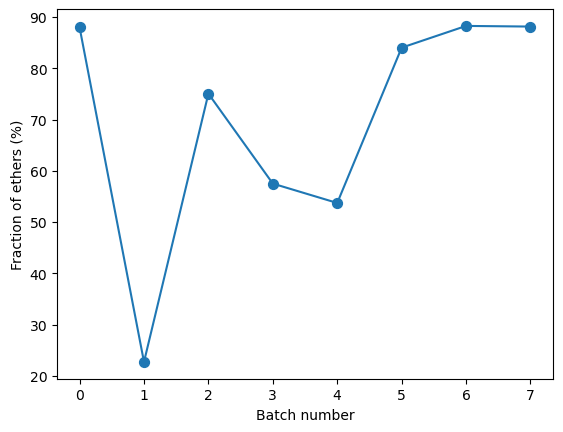

In [122]:
frac_list = [frac_ether_0, frac_ether_1, frac_ether_2, frac_ether_3, frac_ether_4, frac_ether_5, frac_ether_6, frac_ether_7]
plt.scatter(range(0, 8), frac_list, s=50)
plt.plot(range(0, 8), frac_list)
plt.xlabel('Batch number')
plt.ylabel('Fraction of ethers (%)')

Text(0, 0.5, 'Fraction of unique ethers (%)')

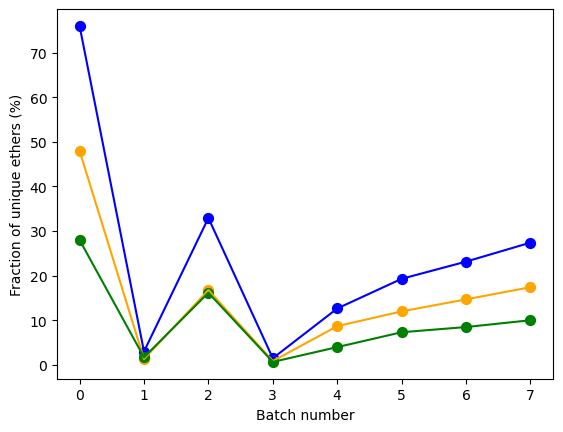

In [123]:
only_ether_tot_list = [frac_only_ether_tot_0, frac_only_ether_tot_1, frac_only_ether_tot_2, frac_only_ether_tot_3, frac_only_ether_tot_4, frac_only_ether_tot_5, frac_only_ether_tot_6, frac_only_ether_tot_7]
only_ether_nonF_list = [frac_only_ether_nonF_0, frac_only_ether_nonF_1, frac_only_ether_nonF_2, frac_only_ether_nonF_3, frac_only_ether_nonF_4, frac_only_ether_nonF_5, frac_only_ether_nonF_6, frac_only_ether_nonF_7]
only_ether_F_list = [frac_only_ether_F_0, frac_only_ether_F_1, frac_only_ether_F_2, frac_only_ether_F_3, frac_only_ether_F_4, frac_only_ether_F_5, frac_only_ether_F_6, frac_only_ether_F_7]
plt.scatter(range(0, 8), only_ether_tot_list, s=50, color='blue')
plt.plot(range(0, 8), only_ether_tot_list, color='blue', label='Total ethers')
plt.scatter(range(0, 8), only_ether_nonF_list, s=50, color='orange')
plt.plot(range(0, 8), only_ether_nonF_list, color='orange', label='Non-F ethers')
plt.scatter(range(0, 8), only_ether_F_list, s=50, color='green')
plt.plot(range(0, 8), only_ether_F_list, color='green', label='F ethers')
plt.xlabel('Batch number')
plt.ylabel('Fraction of unique ethers (%)')

In [110]:
only_ether_tot_list = [frac_only_ether_tot_0, frac_only_ether_tot_1, frac_only_ether_tot_2, frac_only_ether_tot_3, frac_only_ether_tot_4, frac_only_ether_tot_5, frac_only_ether_tot_6, frac_only_ether_tot_7]
only_ether_nonF_list = [frac_only_ether_nonF_0, frac_only_ether_nonF_1, frac_only_ether_nonF_2, frac_only_ether_nonF_3, frac_only_ether_nonF_4, frac_only_ether_nonF_5, frac_only_ether_nonF_6, frac_only_ether_nonF_7]
only_ether_F_list = [frac_only_ether_F_0, frac_only_ether_F_1, frac_only_ether_F_2, frac_only_ether_F_3, frac_only_ether_F_4, frac_only_ether_F_5, frac_only_ether_F_6, frac_only_ether_F_7]

In [111]:
only_ether_df = pd.DataFrame({
    'Batch number': range(0, 8),
    'Total ethers (%)': only_ether_tot_list,
    'Non-F ethers (%)': only_ether_nonF_list,
    'F ethers (%)': only_ether_F_list
})
only_ether_df

,Batch number,Total ethers (%),Non-F ethers (%),F ethers (%)
0,0,76.923077,46.153846,30.769231
1,1,2.980000,1.300000,1.680000
2,2,32.943055,16.764236,16.178819
3,3,1.473095,0.827855,0.645240
4,4,12.630015,8.663847,3.966168
5,5,19.283857,11.982396,7.301460
6,6,23.142077,14.672131,8.469945
7,7,24.091118,16.014726,8.076392


### Plot fraction of ethers (total & "only") for suggested compounds: Fig 2c in main article

In [112]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118

In [114]:
# only_ether_df_sugg = pd.read_csv('frac_only_ether_sugg_091824.csv')
only_ether_df_sugg = only_ether_df.copy()
only_ether_df_sugg.drop(index=[0,7], inplace=True)
only_ether_df_sugg.reset_index(drop=True, inplace=True)
only_ether_df_sugg

,Batch number,Total ethers (%),Non-F ethers (%),F ethers (%)
0,1,2.980000,1.300000,1.680000
1,2,32.943055,16.764236,16.178819
2,3,1.473095,0.827855,0.645240
3,4,12.630015,8.663847,3.966168
4,5,19.283857,11.982396,7.301460
5,6,23.142077,14.672131,8.469945


(-2.0, 100.0)

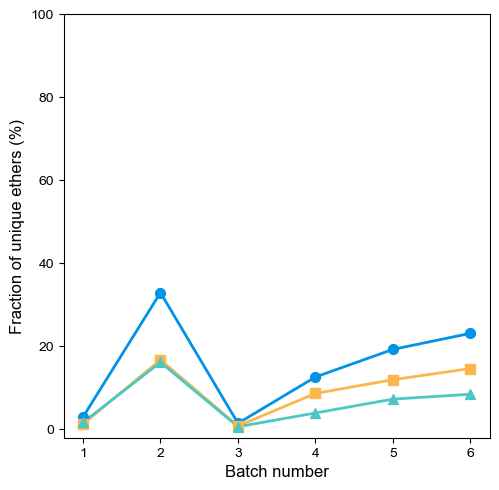

In [115]:
cols_sugg = only_ether_df_sugg.columns
fig, ax = plt.subplots(figsize=(5.5, 5.5))
plt.scatter(only_ether_df_sugg['Batch number'], only_ether_df_sugg['Total ethers (%)'], s=50, color=blue, zorder=2)
plt.plot(only_ether_df_sugg['Batch number'], only_ether_df_sugg['Total ethers (%)'], color=blue, label='Total ethers', zorder=1, linewidth=2)
plt.scatter(only_ether_df_sugg['Batch number'], only_ether_df_sugg['Non-F ethers (%)'], s=50, color=orange, zorder=2, marker='s')
plt.plot(only_ether_df_sugg['Batch number'], only_ether_df_sugg['Non-F ethers (%)'], color=orange, label='Non-F ethers', zorder=1, linewidth=2)
plt.scatter(only_ether_df_sugg['Batch number'], only_ether_df_sugg['F ethers (%)'], s=50, color=anvil, zorder=2, marker='^')
plt.plot(only_ether_df_sugg['Batch number'], only_ether_df_sugg['F ethers (%)'], color=anvil, label='F ethers', zorder=1, linewidth=2)
plt.xlabel('Batch number', fontsize=12)
plt.ylabel('Fraction of unique ethers (%)', fontsize=12)
plt.ylim(-2, 100)

### Plot fraction of ethers (total & "only") for labeled compounds: Fig. 2d in main article

In [119]:
df_tt = pd.read_csv('../../datasets/label_all_batches_feat.csv')
df_tt

,solv_comb_sm,salt_comb_sm,batch,solv_ecfp_pca_0,solv_ecfp_pca_1,solv_ecfp_pca_2,solv_ecfp_pca_3,solv_ecfp_pca_4,solv_ecfp_pca_5,solv_ecfp_pca_6,...,norm_capacity_15,norm_capacity_16,norm_capacity_17,norm_capacity_18,norm_capacity_19,norm_capacity_20,norm_capacity_21,norm_capacity_22,norm_capacity_23,expt_test
0,COCCOC,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.0,-0.845301,-0.995151,1.062720,-0.357552,-0.308720,0.309456,0.693325,...,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,COCCOC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.0,-1.183255,-0.948338,0.615257,-0.582269,-1.010187,-0.522075,0.496896,...,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.0,-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,...,0.02168,0.022967,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,COCCOCC(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.0,-1.240814,-0.970769,0.671105,-0.607789,-1.124651,-0.436617,0.628824,...,0.00046,0.000360,0.000407,0.0006,0.000593,0.000447,0.000333,0.0,0.0,0.0
4,CCOCCOC(C)(C)C,O=S(=O)(F)[N-]S(=O)(=O)F.[Li+],0.0,-0.879184,-1.539457,0.507075,-0.111830,0.800175,0.133053,0.926130,...,0.00000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,CCOCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
204,COCCCCOCC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
205,COCCCOCC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
206,COCCCOCC(F)(F)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0


In [120]:
df_b1_aq = df_tt.loc[df_tt['expt_test'] == 1][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b2_aq = df_tt.loc[df_tt['expt_test'] == 2][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b3_aq = df_tt.loc[df_tt['expt_test'] == 3][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b4_aq = df_tt.loc[df_tt['expt_test'] == 4][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b5_aq = df_tt.loc[df_tt['expt_test'] == 5][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b6_aq = df_tt.loc[df_tt['expt_test'] == 6][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b7_aq = df_tt.loc[df_tt['expt_test'] == 7][['solv_comb_sm', 'salt_comb_sm', 'norm_capacity_3', 'theor_capacity', 'expt_test']]
df_b7_aq

,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test
199,COCCOS(=O)(=O)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,7.0
200,COCCOCC(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.770667,150.0,7.0
201,COC1CCCCO1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.229333,150.0,7.0
202,CCCCOCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.776667,150.0,7.0
203,CCOCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.772000,150.0,7.0
204,COCCCCOCC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.726000,150.0,7.0
205,COCCCOCC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.442000,150.0,7.0
206,COCCCOCC(F)(F)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.820000,150.0,7.0
207,COCCCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000067,150.0,7.0


#### Batch: 1

In [121]:
df_b1_aq_uniq = df_b1_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b1_aq_uniq.reset_index(drop=True, inplace=True)
df_b1_aq_, classes_b1_aq, class_arr_b1_aq = calc_func_grp_frac(df_b1_aq_uniq, 'solv_comb_sm')
df_b1_aq_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,CN1C(C)(C)CCCC1(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Amine]
1,CC1(C)CCCC(C)(C)N1Cl,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Amine]
2,CN1CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Amine]
3,CCN1CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Amine]
4,CC1(C(=O)Cl)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Others]
5,CC1(C)CCCC(=O)C1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000067,150.0,1.0,[Ketone]
6,O=C1CC(=O)CC2(CCCC2)C1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Ketone]
7,COC(=O)C1(C)CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.001067,150.0,1.0,[Ester]
8,FC1(F)CCCCC1Cl,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Others]
9,FC1(F)CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,1.0,[Others]


In [122]:
ether_len_b1_aq = len(set(classes_b1_aq['Ether']))
frac_ether_b1_aq = ether_len_b1_aq/len(df_b1_aq_uniq)*100
frac_ether_b1_aq

0.0

In [123]:
## mutually exclusive classification for ethers
only_ether_b1_aq_tot = df_b1_aq_[
    df_b1_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b1_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b1_aq_nonF = df_b1_aq_[
    df_b1_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b1_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b1_aq = len(only_ether_b1_aq_tot['solv_comb_sm'].unique())/len(df_b1_aq_uniq)*100
frac_only_ether_tot_b1_aq

0.0

In [124]:
frac_only_ether_nonF_b1_aq = len(only_ether_b1_aq_nonF['solv_comb_sm'].unique())/len(df_b1_aq_uniq)*100
frac_only_ether_nonF_b1_aq

0.0

#### Batch: 2

In [125]:
df_b2_aq_uniq = df_b2_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b2_aq_uniq.reset_index(drop=True, inplace=True)
df_b2_aq_, classes_b2_aq, class_arr_b2_aq = calc_func_grp_frac(df_b2_aq_uniq, 'solv_comb_sm')
df_b2_aq_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,COC(OC)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,2.0,[Ether]
1,COCC(F)(F)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,2.0,[Ether]
2,COC(CC(F)(F)F)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.375106,150.0,2.0,[Ether]
3,COCCC(C)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000007,150.0,2.0,[Ether]
4,COCC(C)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000007,150.0,2.0,[Ether]
5,CO[Si](CCC(F)(F)C(F)(F)C(F)(F)F)(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.010000,150.0,2.0,[Silyl ether]
6,COCCOCOCC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.039613,150.0,2.0,[Ether]
7,COC(CCl)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,2.0,[Ether]
8,COC(F)(F)C(F)Cl,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,2.0,[Ether]
9,COC(C)CC(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000600,150.0,2.0,[Ether]


In [126]:
ether_len_b2_aq = len(set(classes_b2_aq['Ether']))
frac_ether_b2_aq = ether_len_b2_aq/len(df_b2_aq_uniq)*100
frac_ether_b2_aq

90.9090909090909

In [127]:
## mutually exclusive classification for ethers
only_ether_b2_aq_tot = df_b2_aq_[
    df_b2_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b2_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b2_aq_nonF = df_b2_aq_[
    df_b2_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b2_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b2_aq = len(only_ether_b2_aq_tot['solv_comb_sm'].unique())/len(df_b2_aq_uniq)*100
frac_only_ether_tot_b2_aq

72.72727272727273

In [128]:
frac_only_ether_nonF_b2_aq = len(only_ether_b2_aq_nonF['solv_comb_sm'].unique())/len(df_b2_aq_uniq)*100
frac_only_ether_nonF_b2_aq

36.36363636363637

#### Batch: 3

In [129]:
df_b3_aq_uniq = df_b3_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b3_aq_uniq.reset_index(drop=True, inplace=True)
df_b3_aq_, classes_b3_aq, class_arr_b3_aq = calc_func_grp_frac(df_b3_aq_uniq, 'solv_comb_sm')
df_b3_aq_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,COCCOCCOCC(F)(F)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.549597,150.0,3.0,[Ether]
1,CCCCOCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.249267,150.0,3.0,[Ether]
2,CCCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.536540,150.0,3.0,[Ether]
3,CCOC(=O)CN(C)CCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000008,150.0,3.0,"[Ester, Ether, Amine]"
4,COCCN(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000007,150.0,3.0,"[Ether, Amine]"
5,CCOCCCl,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,3.0,[Ether]
6,COCCN(C)S(C)(=O)=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,3.0,"[Ether, Amine]"


In [130]:
ether_len_b3_aq = len(set(classes_b3_aq['Ether']))
frac_ether_b3_aq = ether_len_b3_aq/len(df_b3_aq_uniq)*100
frac_ether_b3_aq

100.0

In [131]:
## mutually exclusive classification for ethers
only_ether_b3_aq_tot = df_b3_aq_[
    df_b3_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b3_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b3_aq_nonF = df_b3_aq_[
    df_b3_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b3_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b3_aq = len(only_ether_b3_aq_tot['solv_comb_sm'].unique())/len(df_b3_aq_uniq)*100
frac_only_ether_tot_b3_aq

42.857142857142854

In [132]:
frac_only_ether_nonF_b3_aq = len(only_ether_b3_aq_nonF['solv_comb_sm'].unique())/len(df_b3_aq_uniq)*100
frac_only_ether_nonF_b3_aq

28.57142857142857

#### Batch: 4

In [133]:
df_b4_aq_uniq = df_b4_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b4_aq_uniq.reset_index(drop=True, inplace=True)
df_b4_aq_, classes_b4_aq, class_arr_b4_aq = calc_func_grp_frac(df_b4_aq_uniq, 'solv_comb_sm')
df_b4_aq_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,CCCCCCOC=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000100,150.0,4.0,[Ether]
1,CCCCCCOS(C)(=O)=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.003003,150.0,4.0,[Sulfonate ester]
2,CCCCCOCCCCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.054967,150.0,4.0,[Ether]
3,CCCCOCCCl,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,4.0,[Ether]
4,CCCCOCCOCCCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.154258,150.0,4.0,[Ether]
5,CCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.634300,150.0,4.0,[Ether]
6,CCCCCCON=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,4.0,[Amine]
7,CO[Si](CCC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(...,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,4.0,[Silyl ether]
8,CCCCC(OCC)OCC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,4.0,[Ether]


In [134]:
ether_len_b4_aq = len(set(classes_b4_aq['Ether']))
frac_ether_b4_aq = ether_len_b4_aq/len(df_b4_aq_uniq)*100
frac_ether_b4_aq

66.66666666666666

In [135]:
## mutually exclusive classification for ethers
only_ether_b4_aq_tot = df_b4_aq_[
    df_b4_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b4_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b4_aq_nonF = df_b4_aq_[
    df_b4_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b4_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b4_aq = len(only_ether_b4_aq_tot['solv_comb_sm'].unique())/len(df_b4_aq_uniq)*100
frac_only_ether_tot_b4_aq

44.44444444444444

In [136]:
frac_only_ether_nonF_b4_aq = len(only_ether_b4_aq_nonF['solv_comb_sm'].unique())/len(df_b4_aq_uniq)*100
frac_only_ether_nonF_b4_aq

44.44444444444444

#### Batch: 5

In [137]:
df_b5_aq_uniq = df_b5_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b5_aq_uniq.reset_index(drop=True, inplace=True)
df_b5_aq_, classes_b5_aq, class_arr_b5_aq = calc_func_grp_frac(df_b5_aq_uniq, 'solv_comb_sm')
df_b5_aq_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,COCCOCC(OC)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000067,150.0,5.0,[Ether]
1,COCCCCCl,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,5.0,[Ether]
2,COCC(F)(F)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,5.0,[Ether]
3,CCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.674600,150.0,5.0,[Ether]
4,COC1CCCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.587033,150.0,5.0,[Ether]
5,COCCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.379667,150.0,5.0,[Ether]
6,COCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.746900,150.0,5.0,[Ether]
7,COCCCOCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.588500,150.0,5.0,[Ether]
8,CS(=O)(=O)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,5.0,[Sulfonyl fluoride]
9,COC(CCl)(CCl)OC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,5.0,[Ether]


In [138]:
ether_len_b5_aq = len(set(classes_b5_aq['Ether']))
frac_ether_b5_aq = ether_len_b5_aq/len(df_b5_aq_uniq)*100
frac_ether_b5_aq

90.9090909090909

In [139]:
## mutually exclusive classification for ethers
only_ether_b5_aq_tot = df_b5_aq_[
    df_b5_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b5_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b5_aq_nonF = df_b5_aq_[
    df_b5_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b5_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b5_aq = len(only_ether_b5_aq_tot['solv_comb_sm'].unique())/len(df_b5_aq_uniq)*100
frac_only_ether_tot_b5_aq

63.63636363636363

In [140]:
frac_only_ether_nonF_b5_aq = len(only_ether_b5_aq_nonF['solv_comb_sm'].unique())/len(df_b5_aq_uniq)*100
frac_only_ether_nonF_b5_aq

54.54545454545454

#### Batch: 6

In [141]:
df_b6_aq_uniq = df_b6_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b6_aq_uniq.reset_index(drop=True, inplace=True)
df_b6_aq_, classes_b6_aq, class_arr_b6_aq = calc_func_grp_frac(df_b6_aq_uniq, 'solv_comb_sm')
df_b6_aq_

/var/folders/s5/lmr5dh0n4bsgnpxrzwlts5lw0000gn/T/ipykernel_87932/1027943715.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = class_arr


,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,COCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.468241,150.0,6.0,[Ether]
1,COCCOCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.506254,150.0,6.0,[Ether]
2,COC1CCCC1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.827567,150.0,6.0,[Ether]
3,COCCCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.462400,150.0,6.0,[Ether]
4,COC(=O)C1CCCCCC1=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,6.0,"[Ester, Ketone]"
5,COCCOCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.713863,150.0,6.0,[Ether]
6,CCCCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.442987,150.0,6.0,[Ether]
7,CCOCCOCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.666620,150.0,6.0,[Ether]
8,COC1CCCCC1=O,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,6.0,"[Ether, Ketone]"
9,COCCS(=O)(=O)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.264730,150.0,6.0,"[Sulfonyl fluoride, Ether]"


In [142]:
ether_len_b6_aq = len(set(classes_b6_aq['Ether']))
frac_ether_b6_aq = ether_len_b6_aq/len(df_b6_aq_uniq)*100
frac_ether_b6_aq

90.9090909090909

In [143]:
## mutually exclusive classification for ethers
only_ether_b6_aq_tot = df_b6_aq_[
    df_b6_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b6_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b6_aq_nonF = df_b6_aq_[
    df_b6_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b6_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b6_aq = len(only_ether_b6_aq_tot['solv_comb_sm'].unique())/len(df_b6_aq_uniq)*100
frac_only_ether_tot_b6_aq

63.63636363636363

In [144]:
frac_only_ether_nonF_b6_aq = len(only_ether_b6_aq_nonF['solv_comb_sm'].unique())/len(df_b6_aq_uniq)*100
frac_only_ether_nonF_b6_aq

63.63636363636363

#### Batch: 7

In [145]:
df_b7_aq_uniq = df_b7_aq.drop_duplicates(subset=['solv_comb_sm'])
df_b7_aq_uniq.reset_index(drop=True, inplace=True)
df_b7_aq_, classes_b7_aq, class_arr_b7_aq = calc_func_grp_frac(df_b7_aq_uniq, 'solv_comb_sm')
df_b7_aq_

,solv_comb_sm,salt_comb_sm,norm_capacity_3,theor_capacity,expt_test,class
0,COCCOS(=O)(=O)C(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000000,150.0,7.0,"[Sulfonate ester, Ether]"
1,COCCOCC(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.770667,150.0,7.0,[Ether]
2,COC1CCCCO1,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.229333,150.0,7.0,[Ether]
3,CCCCOCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.776667,150.0,7.0,[Ether]
4,CCOCCCCOC,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.772000,150.0,7.0,[Ether]
5,COCCCCOCC(F)(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.726000,150.0,7.0,[Ether]
6,COCCCOCC(C)(C)C,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.442000,150.0,7.0,[Ether]
7,COCCCOCC(F)(F)C(F)F,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.820000,150.0,7.0,[Ether]
8,COCCCF,[Li+].[N-](S(=O)(=O)F)S(=O)(=O)F,0.000067,150.0,7.0,[Ether]


In [146]:
ether_len_b7_aq = len(set(classes_b7_aq['Ether']))
frac_ether_b7_aq = ether_len_b7_aq/len(df_b7_aq_uniq)*100
frac_ether_b7_aq

100.0

In [147]:
## mutually exclusive classification for ethers
only_ether_b7_aq_tot = df_b7_aq_[
    df_b7_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b7_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si")
]

only_ether_b7_aq_nonF = df_b7_aq_[
    df_b7_aq_['class'].apply(lambda x: 'Ether' in x and len(x) == 1) &
    ~df_b7_aq_['solv_comb_sm'].str.contains("N|S|P|Cl|Br|I|Al|B|=|#|Si|F")
]

frac_only_ether_tot_b7_aq = len(only_ether_b7_aq_tot['solv_comb_sm'].unique())/len(df_b7_aq_uniq)*100
frac_only_ether_tot_b7_aq

88.88888888888889

In [148]:
frac_only_ether_nonF_b7_aq = len(only_ether_b7_aq_nonF['solv_comb_sm'].unique())/len(df_b7_aq_uniq)*100
frac_only_ether_nonF_b7_aq

44.44444444444444

In [149]:
only_ether_tot_list_aq = [frac_only_ether_tot_0, frac_only_ether_tot_b1_aq, frac_only_ether_tot_b2_aq, frac_only_ether_tot_b3_aq, frac_only_ether_tot_b4_aq, frac_only_ether_tot_b5_aq, frac_only_ether_tot_b6_aq, frac_only_ether_tot_b7_aq]
only_ether_nonF_list_aq = [frac_only_ether_nonF_0, frac_only_ether_nonF_b1_aq, frac_only_ether_nonF_b2_aq, frac_only_ether_nonF_b3_aq, frac_only_ether_nonF_b4_aq, frac_only_ether_nonF_b5_aq, frac_only_ether_nonF_b6_aq, frac_only_ether_nonF_b7_aq]
only_ether_F_list_aq = [frac_only_ether_F_0, frac_only_ether_tot_b1_aq - frac_only_ether_nonF_b1_aq, frac_only_ether_tot_b2_aq - frac_only_ether_nonF_b2_aq, frac_only_ether_tot_b3_aq - frac_only_ether_nonF_b3_aq, frac_only_ether_tot_b4_aq - frac_only_ether_nonF_b4_aq, frac_only_ether_tot_b5_aq - frac_only_ether_nonF_b5_aq, frac_only_ether_tot_b6_aq - frac_only_ether_nonF_b6_aq, frac_only_ether_tot_b7_aq - frac_only_ether_nonF_b7_aq]
all_ether_list_aq = [frac_ether_0, frac_ether_b1_aq, frac_ether_b2_aq, frac_ether_b3_aq, frac_ether_b4_aq, frac_ether_b5_aq, frac_ether_b6_aq, frac_ether_b7_aq]
only_ether_df_aq = pd.DataFrame({
    'Batch number': range(0, 8),
    'Total ethers (ex | %)': only_ether_tot_list_aq,
    'Non-F ethers (ex | %)': only_ether_nonF_list_aq,
    'F ethers (ex | %)': only_ether_F_list_aq,
    'All ethers (incl | %)': all_ether_list_aq
})

only_ether_df_aq

,Batch number,Total ethers (ex | %),Non-F ethers (ex | %),F ethers (ex | %),All ethers (incl | %)
0,0,76.923077,46.153846,30.769231,88.461538
1,1,0.000000,0.000000,0.000000,0.000000
2,2,72.727273,36.363636,36.363636,90.909091
3,3,42.857143,28.571429,14.285714,100.000000
4,4,44.444444,44.444444,0.000000,66.666667
5,5,63.636364,54.545455,9.090909,90.909091
6,6,63.636364,63.636364,0.000000,90.909091
7,7,88.888889,44.444444,44.444444,100.000000


(-2.0, 100.0)

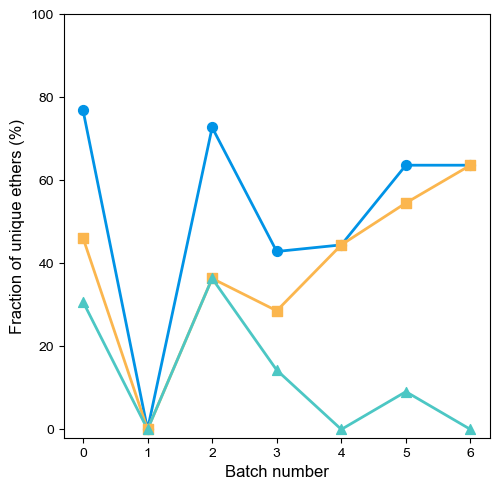

In [ ]:
only_ether_df_aq.drop(index=[7], inplace=True)
cols_aq = only_ether_df_aq.columns
fig, ax = plt.subplots(figsize=(5.5, 5.5))
plt.scatter(only_ether_df_aq['Batch number'], only_ether_df_aq['Total ethers (ex | %)'], s=50, color=blue, zorder=2)
plt.plot(only_ether_df_aq['Batch number'], only_ether_df_aq['Total ethers (ex | %)'], color=blue, label='Total ethers (ex)', zorder=1, linewidth=2)
plt.scatter(only_ether_df_aq['Batch number'], only_ether_df_aq['Non-F ethers (ex | %)'], s=50, color=orange, zorder=2, marker='s')
plt.plot(only_ether_df_aq['Batch number'], only_ether_df_aq['Non-F ethers (ex | %)'], color=orange, label='Non-F ethers (ex)', zorder=1, linewidth=2)
plt.scatter(only_ether_df_aq['Batch number'], only_ether_df_aq['F ethers (ex | %)'], s=50, color=anvil, zorder=2, marker='^')
plt.plot(only_ether_df_aq['Batch number'], only_ether_df_aq['F ethers (ex | %)'], color=anvil, label='F ethers (ex)', zorder=1, linewidth=2)
plt.xlabel('Batch number', fontsize=12)
plt.ylabel('Fraction of unique ethers (%)', fontsize=12)
plt.ylim(-2, 100)